# Загрузка библиотек и датасета

In [ ]:
!pip install scikit-uplift catboost econml causalml


In [ ]:
from sklift.datasets import fetch_lenta
from sklift.models import ClassTransformation
from sklift.metrics import uplift_at_k
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
from IPython.display import display, Markdown


warnings.filterwarnings("ignore")


In [ ]:
dataset = fetch_lenta()
data, target, treatment = dataset.data, dataset.target, dataset.treatment


Lenta dataset:   0%|          | 0.00/145M [00:00<?, ?iB/s]

# EDA

Сильно углубляться в EDA не будем, так как цель - сравнить подходы к uplift-моделированиию. Проверим только базовые пункты перед обучением моделей:

- Посмотрим на фичи в датасете
- Посмотрим распределение test/control и target
- Оценим базовый uplift
- Проверем гомогенность разбиения test/control
- Проверим и обработаем NaN

In [ ]:
df = dataset.data.copy()
df['target'] = dataset.target
df['treatment'] = dataset.treatment
gender_dict = {
    'М': 1,
    'Ж': 0
}
treat_dict = {
    'test': 1,
    'control': 0
}
df.treatment = df.treatment.map(treat_dict)
df.gender = df.gender.map(gender_dict)


## Описание датасета

Данные о покупках, активности клиентов Ленты и результатах маркетинговых кампаний

Treatment - смс-пуш с промоакцией

Всего 687К строк

Источник: BigTarget by Lenta and Microsoft, 2020.

Подробнее: [Lenta Dataset sklift](https://www.uplift-modeling.com/en/latest/api/datasets/fetch_lenta.html#lenta-uplift-modeling-dataset)

| **Группа** | **Фичи** | **Описание** |
|---|---|---|
| **ID и базовая инфа** | `CardHolder`<br><br>`age`<br><br>`gender`<br><br>`children`<br><br>`months_from_register`<br><br>`main_format` | Идентификатор клиента и базовые характеристики: возраст, пол, дети, стаж, тип магазина |
| **Таргет и эксперимент** | `response_att`<br><br>`group` | Целевая переменная (визит) и флаг treatment/control |
| **Коммуникации (история откликов)** | `response_sms`<br><br>`response_viber` | Доля откликов на прошлые коммуникации |
| **Покупательская активность (RFM-like)** | `cheque_count_[3,6,12]m_g*`<br><br>`sale_count_[3,6,12]m_g*`<br><br>`sale_sum_[3,6,12]m_g*` | Частота покупок, количество товаров и выручка по группам товаров |
| **Промо / скидки (уровень)** | `disc_sum_6m_g34`<br><br>`mean_discount_depth_15d`<br><br>`promo_share_15d`<br><br>`food_share_[15d,1m]` | Объем скидок, глубина скидок, доля промо и структура покупок |
| **Промо-поведение (crazy campaigns)** | `crazy_purchases_cheque_count_[1,3,6,12]m`<br><br>`crazy_purchases_goods_count_[6,12]m` | Активность клиента в “агрессивных” промо |
| **Поведение визитов** | `k_var_days_between_visits_[15d,1m,3m]`<br><br>`stdev_days_between_visits_15d`<br><br>`perdelta_days_between_visits_15_30d` | Регулярность и паттерны посещений |
| **Размер и состав чека** | `k_var_cheque_[15d,3m]`<br><br>`k_var_count_per_cheque_[15d,1m,3m,6m]_g*`<br><br>`k_var_sku_per_cheque_15d` | Вариативность размера чека и количества товаров |
| **Разнообразие покупок** | `k_var_cheque_category_width_15d`<br><br>`k_var_cheque_group_width_15d` | Разнообразие категорий и групп в корзине |
| **Цены и скидки (вариативность)** | `k_var_disc_per_cheque_15d`<br><br>`k_var_disc_share_[15d,1m,3m,6m,12m]_g*`<br><br>`k_var_discount_depth_[15d,1m]`<br><br>`stdev_discount_depth_[15d,1m]`<br><br>`k_var_sku_price_12m_g*` | Насколько нестабильны цены и скидки |

## Распределение treatment и target. Общий uplift

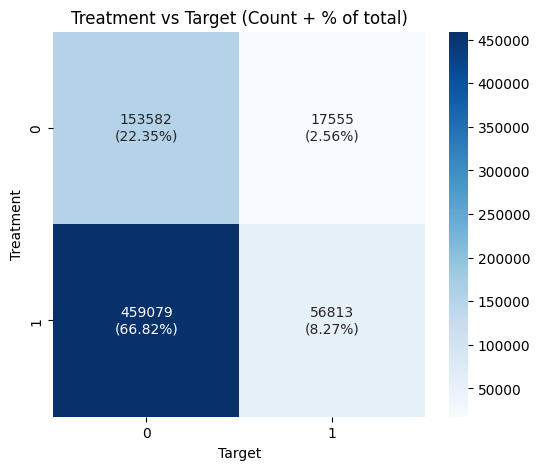

In [ ]:
def plot_combined_matrix(df, treatment_col='treatment', target_col='target'):
    cm = pd.crosstab(df[treatment_col], df[target_col])
    cm_pct = cm / cm.values.sum()

    labels = np.array([
        f"{cm.iloc[i, j]}\n({cm_pct.iloc[i, j]:.2%})"
        for i in range(cm.shape[0])
        for j in range(cm.shape[1])
    ]).reshape(cm.shape)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')

    plt.title('Treatment vs Target (Count + % of total)')
    plt.xlabel('Target')
    plt.ylabel('Treatment')
    plt.show()


plot_combined_matrix(df)


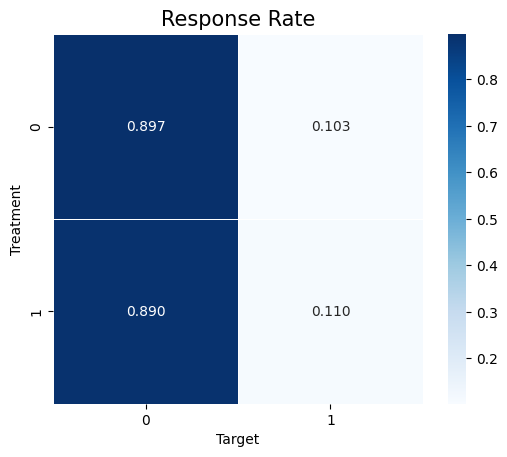

In [ ]:
def crosstab_plot(treatment, target):
    ct = pd.crosstab(treatment, target, normalize='index')

    sns.heatmap(ct, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues')
    plt.ylabel('Treatment')
    plt.xlabel('Target')
    plt.title("Response Rate", size = 15)

crosstab_plot(df.treatment, df.target)


In [ ]:
p_t = df[df['treatment'] == 1]['target'].mean()
p_c = df[df['treatment'] == 0]['target'].mean()

n_t = (df['treatment'] == 1).sum()
n_c = (df['treatment'] == 0).sum()

uplift = p_t - p_c
se = np.sqrt(p_t * (1 - p_t) / n_t + p_c * (1 - p_c) / n_c)

ci_low = uplift - 1.96 * se
ci_high = uplift + 1.96 * se

print(f"uplift: {uplift:.4f}")
print(f"95% Доверительный интервал: [{ci_low:.4f}, {ci_high:.4f}]")


uplift: 0.0075
95% CI: [0.0059, 0.0092]


**Выводы:**

Соотношение Test/Control: 75/25

Разница в Response Rate (Общий Uplift) по датасету: +0.7%

Доверительный интервал для uplift: [+0.6%, +0.9%]

## Распределение признаков в test/control

Далее сравним распредления признаков в контроле и тесте, чтобы убедиться, что разбиение гомогенное

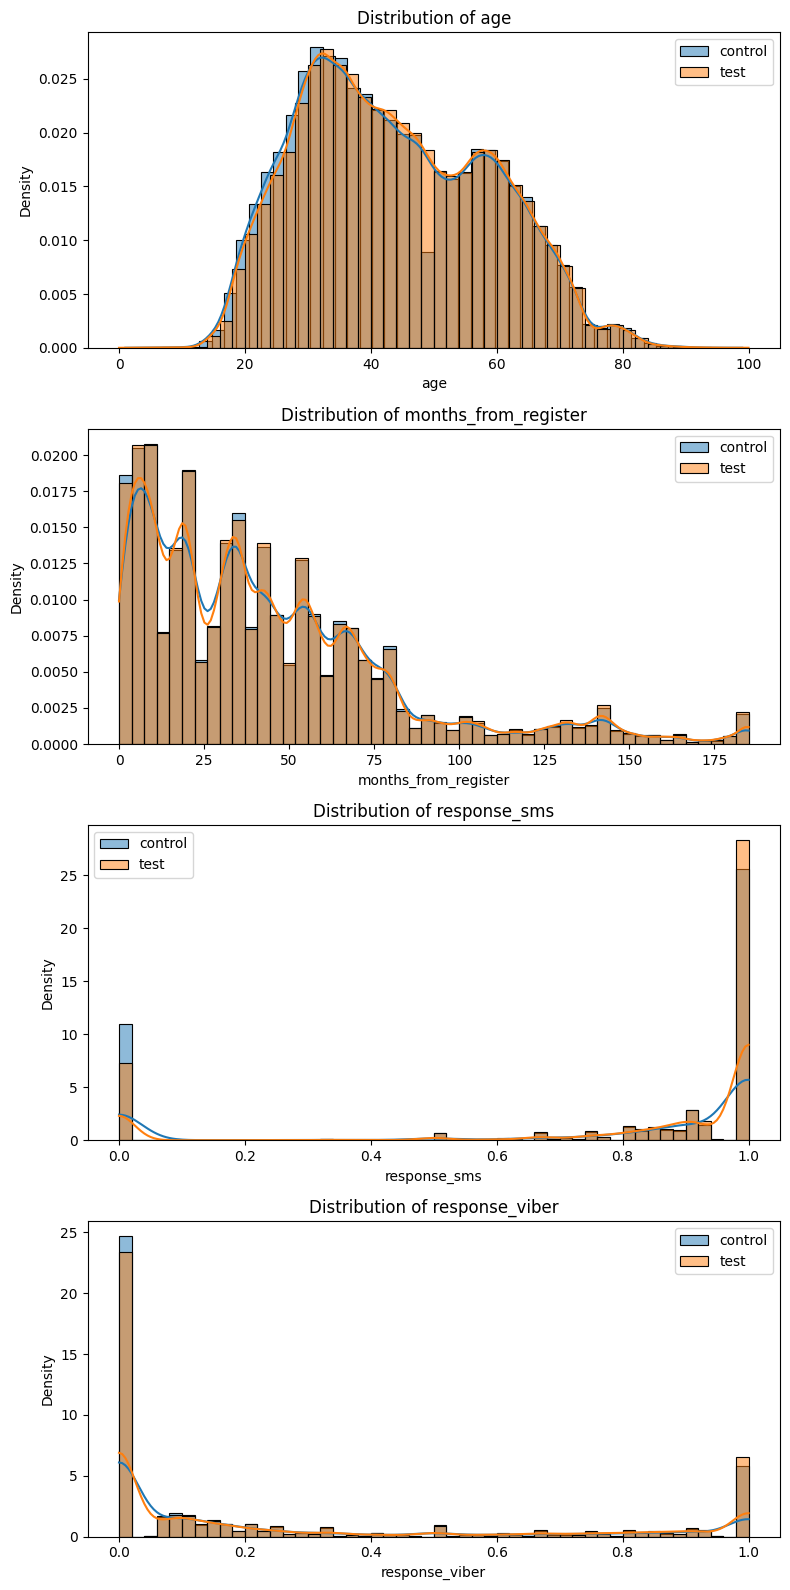

In [ ]:
def plot_distributions(df, features, treatment_col='treatment'):
    test = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]

    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(8, 4 * n))

    if n == 1:
        axes = [axes]

    for i, feature in enumerate(features):
        ax = axes[i]

        sns.histplot(
            control[feature],
            bins=50,
            stat='density',
            kde=True,
            label='control',
            ax=ax,
            alpha=0.5
        )

        sns.histplot(
            test[feature],
            bins=50,
            stat='density',
            kde=True,
            label='test',
            ax=ax,
            alpha=0.5
        )

        ax.set_title(f'Distribution of {feature}')
        ax.legend()

    plt.tight_layout()
    plt.show()


features = [
    'age',
    'months_from_register',
    'response_sms',
    'response_viber'
]

plot_distributions(df, features)


In [ ]:
def balance_table(df, features, treatment_col='treatment'):
    results = []

    control = df[df[treatment_col] == 0]
    test = df[df[treatment_col] == 1]

    for col in features:
        row = {}
        row['feature'] = col

        x_control = control[col].dropna()
        x_test = test[col].dropna()

        unique_vals = df[col].dropna().unique()
        is_binary = len(unique_vals) == 2

        ctrl_mean = x_control.mean()
        test_mean = x_test.mean()

        abs_diff = test_mean - ctrl_mean

        if ctrl_mean != 0:
            rel_diff = abs_diff / ctrl_mean
        else:
            rel_diff = np.nan

        if is_binary:
            row['type'] = 'binary'

            pooled_p = (ctrl_mean + test_mean) / 2
            denom = np.sqrt(pooled_p * (1 - pooled_p))

            if denom != 0:
                std_diff = abs_diff / denom
            else:
                std_diff = np.nan

        else:
            row['type'] = 'numeric'

            ctrl_var = x_control.var()
            test_var = x_test.var()
            pooled_std = np.sqrt((ctrl_var + test_var) / 2)

            if pooled_std != 0:
                std_diff = abs_diff / pooled_std
            else:
                std_diff = np.nan

        row['control'] = ctrl_mean
        row['test'] = test_mean
        row['abs_diff'] = abs_diff
        row['relative_diff'] = rel_diff
        row['std_diff'] = std_diff

        results.append(row)

    res = pd.DataFrame(results)

    return res.sort_values('std_diff', ascending=False)


In [ ]:
features = [
    'age',
    'gender',
    'children',
    'main_format',
    'months_from_register',
    'response_sms',
    'response_viber',
]
balance_df = balance_table(df, df.columns[:-2:])
display(balance_df)


,feature,type,control,test,abs_diff,relative_diff,std_diff
155,response_sms,numeric,0.726143,0.800636,0.074493,0.102588,0.197907
156,response_viber,numeric,0.250909,0.276202,0.025293,0.100805,0.068491
64,k_var_count_per_cheque_1m_g34,numeric,0.210156,0.218477,0.008320,0.039591,0.025344
46,crazy_purchases_cheque_count_12m,numeric,2.406271,2.520365,0.114094,0.047415,0.024931
50,crazy_purchases_goods_count_12m,numeric,4.037707,4.243799,0.206092,0.051042,0.024411
...,...,...,...,...,...,...,...
24,cheque_count_3m_g56,numeric,0.596929,0.598100,0.001170,0.001960,0.000849
175,sale_sum_12m_g27,numeric,1304.190841,1300.203103,-3.987739,-0.003058,-0.000661
34,cheque_count_6m_g40,numeric,4.199185,4.180541,-0.018644,-0.004440,-0.001988
150,main_format,binary,0.103560,0.100498,-0.003063,-0.029572,-0.010118


Видим что по standardized difference выделяется признак response_sms. Можем посмотреть uplift в бинах по этому признаку

In [ ]:
def uplift_by_feature_bins(
    df,
    feature,
    treatment_col='treatment',
    target_col='target',
    n_bins=5,
    min_bin_size=100
):
    data = df[[feature, treatment_col, target_col]].copy()
    data = data.dropna(subset=[feature, treatment_col, target_col])

    unique_vals = data[feature].nunique()

    if unique_vals <= 5:
        data['feature_bin'] = data[feature].astype(str)

    else:
        data['feature_bin'] = pd.qcut(
            data[feature],
            q=n_bins,
            duplicates='drop'
        )

    grouped = (
        data
        .groupby('feature_bin', observed=True)
        .apply(lambda x: pd.Series({
            'n_control': (x[treatment_col] == 0).sum(),
            'n_test': (x[treatment_col] == 1).sum(),
            'response_control': x.loc[x[treatment_col] == 0, target_col].mean(),
            'response_test': x.loc[x[treatment_col] == 1, target_col].mean(),
        }))
        .reset_index()
    )

    grouped['uplift'] = grouped['response_test'] - grouped['response_control']
    grouped['feature'] = feature
    grouped['n_total'] = grouped['n_control'] + grouped['n_test']

    grouped = grouped[
        [
            'feature',
            'feature_bin',
            'n_control',
            'n_test',
            'response_control',
            'response_test',
            'uplift',
            'n_total'
        ]
    ]

    grouped = grouped[grouped['n_total'] >= min_bin_size]

    return grouped


In [ ]:
uplift_by_feature_bins(df, 'response_sms')


,feature,feature_bin,n_control,n_test,response_control,response_test,uplift,n_total
0,response_sms,"(-0.001, 0.667]",45311.0,96824.0,0.084924,0.084173,-0.000751,142135.0
1,response_sms,"(0.667, 0.917]",32201.0,104674.0,0.120959,0.127357,0.006398,136875.0
2,response_sms,"(0.917, 1.0]",91539.0,307899.0,0.103333,0.111001,0.007668,399438.0


Видим что общий uplift +0.7 п.п. сохраняется при response_sms > 0.67. При меньшем его практически нет. Можно предположить, что клиенты с долей реакций на смс ниже этого порога в целом не будут реагировать на treatment

In [ ]:
uplift_by_feature_bins(df, 'months_from_register')


,feature,feature_bin,n_control,n_test,response_control,response_test,uplift,n_total
0,months_from_register,"(-0.001, 11.0]",37478.0,112168.0,0.092534,0.099520,0.006986,149646.0
1,months_from_register,"(11.0, 27.0]",30766.0,92589.0,0.098193,0.105585,0.007392,123355.0
2,months_from_register,"(27.0, 44.0]",35427.0,106276.0,0.098569,0.105330,0.006761,141703.0
3,months_from_register,"(44.0, 67.0]",32835.0,99055.0,0.103152,0.108233,0.005081,131890.0
4,months_from_register,"(67.0, 185.0]",32545.0,99309.0,0.117806,0.128931,0.011125,131854.0


У старичков в сервисе (>5 лет в сервисе) uplift выше в 2 раза, чем у других. При этом таких клиентов 20% от всей базы. Возможно попали в сегмент лояльных покупателей

In [ ]:
uplift_by_feature_bins(df, 'crazy_purchases_cheque_count_3m')


,feature,feature_bin,n_control,n_test,response_control,response_test,uplift,n_total
0,crazy_purchases_cheque_count_3m,"(-0.001, 1.0]",150184.0,449462.0,0.081473,0.087396,0.005922,599646.0
1,crazy_purchases_cheque_count_3m,"(1.0, 277.0]",20953.0,66430.0,0.253854,0.263917,0.010063,87383.0


In [ ]:
uplift_by_feature_bins(df, 'crazy_purchases_goods_count_12m')


,feature,feature_bin,n_control,n_test,response_control,response_test,uplift,n_total
0,crazy_purchases_goods_count_12m,"(-0.001, 1.0]",92932.0,273777.0,0.058774,0.063102,0.004328,366709.0
1,crazy_purchases_goods_count_12m,"(1.0, 2.0]",16228.0,48279.0,0.097856,0.101576,0.003721,64507.0
2,crazy_purchases_goods_count_12m,"(2.0, 6.0]",31111.0,95694.0,0.129183,0.132913,0.003731,126805.0
3,crazy_purchases_goods_count_12m,"(6.0, 1047.0]",30866.0,98142.0,0.210134,0.223289,0.013155,129008.0


Видим что клиенты, активно участвовавшие в crazy-промо (>1 покупки за 3мес, >6 товаров за год) имеют uplift в 2-3 раза выше чем остальные. Возможно нашли еще один чувствительный к промо-акциям сегмент

## Пропущенные значения

Далее смотрим пропущенные значения и сравниваем test/control по их количеству

In [ ]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0]


k_var_sku_price_15d_g49           0.722326
k_var_disc_share_15d_g49          0.722181
k_var_count_per_cheque_15d_g34    0.681996
k_var_sku_price_15d_g34           0.681996
k_var_disc_share_15d_g34          0.681874
                                    ...   
cheque_count_6m_g58               0.004534
cheque_count_6m_g57               0.004534
disc_sum_6m_g34                   0.004534
cheque_count_6m_g52               0.004534
crazy_purchases_goods_count_6m    0.000001
Length: 153, dtype: float64

In [ ]:
missing_balance = []

for col in df.columns:
    if col not in ['target', 'treatment']:
        missing_balance.append({
            'feature': col,
            'missing_control': df[df['treatment'] == 0][col].isna().mean(),
            'missing_test': df[df['treatment'] == 1][col].isna().mean()
        })

missing_balance = pd.DataFrame(missing_balance)
missing_balance['diff'] = missing_balance['missing_test'] - missing_balance['missing_control']
missing_balance.sort_values('diff', ascending=False)


,feature,missing_control,missing_test,diff
77,k_var_days_between_visits_15d,0.109970,0.112686,0.002716
190,stdev_days_between_visits_15d,0.109970,0.112686,0.002716
78,k_var_days_between_visits_1m,0.131982,0.134329,0.002347
146,k_var_sku_price_6m_g42,0.236430,0.238286,0.001856
114,k_var_discount_depth_15d,0.203118,0.204872,0.001754
...,...,...,...,...
94,k_var_disc_share_3m_g27,0.344449,0.337838,-0.006611
130,k_var_sku_price_3m_g27,0.344607,0.337941,-0.006666
68,k_var_count_per_cheque_3m_g27,0.344607,0.337941,-0.006666
104,k_var_disc_share_3m_g49,0.378521,0.371221,-0.007300


По доле NaN в признаках тест и контроль не отличаются. В контексте истории покупок и активности пользователя можно NaN заполнить нулями

In [ ]:
df = df.fillna(0)


## Разбиение данных перед обучением

Обучение: 70% (481К)

Тест для сравнения моделей: 15% (103К)

Ходаут датасет для симуляции среды в приложении: 15% (103К)

Стратифицируем по target и treatment одновременно

In [ ]:
def split_uplift_data(
    df,
    treatment_col='treatment',
    target_col='target',
    train_size=0.6,
    model_test_size=0.2,
    simulation_test_size=0.2,
    random_state=42
):

    data = df.copy()

    data['_strata'] = (
        data[treatment_col].astype(str) + '_' + data[target_col].astype(str)
    )

    remaining, simulation_test = train_test_split(
        data,
        test_size=simulation_test_size,
        random_state=random_state,
        stratify=data['_strata']
    )

    model_test_relative_size = model_test_size / (train_size + model_test_size)

    train_pool, model_test = train_test_split(
        remaining,
        test_size=model_test_relative_size,
        random_state=random_state,
        stratify=remaining['_strata']
    )

    train_pool = train_pool.drop(columns=['_strata'])
    model_test = model_test.drop(columns=['_strata'])
    simulation_test = simulation_test.drop(columns=['_strata'])

    return train_pool, model_test, simulation_test


train_pool, model_test, simulation_test = split_uplift_data(
    df,
    treatment_col='treatment',
    target_col='target',
    train_size=0.7,
    model_test_size=0.15,
    simulation_test_size=0.15,
    random_state=42
)


In [ ]:
simulation_test.to_csv(
    'simulation_test.csv',
    index=False
)


# Сравнение моделей

Сравним между собой различные модели и подходы к uplift моделированию. Учим каждую модель на всём train, оцениваем качество на test. На данном этапе все гиперпараметры базовых моделей (catboost) фиксированы, тюнить будем только у лучших кандидатов.

## Тестируемые модели:

| Уровень | Модель | Описание |
|---|---|---|
| 0. Baseline | Random | Случайное ранжирование клиентов без ML-модели |
| 0. Baseline | Response Model | Обычная модель отклика (propensity / response), предсказывающая вероятность целевого действия |
| 1. Базовые подходы | S-Learner | Одна модель с treatment-флагом как признаком |
| 1. Базовые подходы | T-Learner | Две независимые модели для treatment и control групп |
| 1. Базовые подходы | Class Transformation | Трансформация таргета в uplift-задачу бинарной классификации |
| 2. Продвинутые подходы | Transformed Outcome | Регрессионная трансформация таргета с учетом propensity score |
| 2. Продвинутые подходы | X-Learner | Две стадии обучения с cross-fitting и оценкой pseudo-uplift |
| 2. Продвинутые подходы | DR-Learner | Doubly Robust uplift-оценка с комбинацией outcome и propensity моделей |
| 2. Продвинутые подходы | Uplift Random Forest | Деревья/лес с uplift-aware split criterion |
| 3. Deep Learning | TARNet | Общий representation backbone + отдельные treatment/control heads |
| 3. Deep Learning | CFRNet + MMD Loss | TARNet с regularization для выравнивания распределений treatment/control |
| 3. Deep Learning | DragonNet | Архитектура с joint learning outcome + propensity + treatment effect |

## Метрики

### Основные uplift-метрики

Отталкиваемся от задачи - выделить сегмент пользователей (размер может меняться), который покажет наибольший uplift при запуске акции. Для этого подойдут метрики, больше опирающиеся на качество ранжирования на основе скора модели

| Метрика | Описание |
|---|---|
| `uplift@5` | Средний uplift на топ-5% клиентов с максимальным предсказанным uplift |
| `uplift@10` | Средний uplift на топ-10% клиентов |
| `uplift@30` | Средний uplift на топ-30% клиентов |
| `Qini AUC` | Площадь под Qini curve, характеризует качество ранжирования uplift |
| `Uplift AUC` | Площадь под uplift curve |


### Оценка ожидаемой прибыли

Чтобы использование моделей было вообще целесообразно, полезно оценить прибыль от акций, запущенных на основе скоринга моделей

**Формулы расчета прибыли**

```python
incremental_visits = uplift * n_selected
gross_profit = incremental_visits * value_per_visit
communication_cost = n_selected * contact_cost
profit = gross_profit - communication_cost
```

Где:

- `uplift` — средний uplift на выбранном сегменте
- `n_selected` — количество клиентов в сегменте
- `value_per_visit` — средняя прибыль с одного дополнительного визита
- `contact_cost` — стоимость коммуникации с одним клиентом

| Параметр | Значение | Комментарий |
|---|---|---|
| Treatment cost | 15 руб. | Стоимость отправки смс-промо |
| Value per visit | 500 руб. | Средний чек с учетом скидки |
| Break-even uplift | 15/500 = 3% | Uplift выше которого выйдем в + |

Получается, чтобы заработать на промоакции, нужно выделить сегмент пользователей, uplift в котором будет в ~7 раз выше чем по всем клиентам в базе

### Profit метрики

| Метрика | Описание |
|---|---|
| `profit@5` | Ожидаемая прибыль при коммуникации с топ-5% клиентов |
| `profit@10` | Ожидаемая прибыль при коммуникации с топ-10% клиентов |
| `profit@30` | Ожидаемая прибыль при коммуникации с топ-30% клиентов |

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
import sklearn.utils
from sklearn.utils._optional_dependencies import check_matplotlib_support
sklearn.utils.check_matplotlib_support = check_matplotlib_support


from catboost import CatBoostClassifier, CatBoostRegressor

from sklift.metrics import (
    uplift_at_k,
    qini_auc_score,
    uplift_auc_score
)

from sklift.viz import (
    plot_qini_curve,
    plot_uplift_curve,
)


In [ ]:
RANDOM_STATE = 42

TARGET_COL = "target"
TREATMENT_COL = "treatment"

CONTACT_COST = 15
VALUE_PER_VISIT = 500

BREAK_EVEN_UPLIFT = CONTACT_COST / VALUE_PER_VISIT
print(f"Break-even uplift: {BREAK_EVEN_UPLIFT:.4f}")


Break-even uplift: 0.0300


In [ ]:
def make_cb_classifier(random_state=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=700,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        task_type="GPU",
        devices="0",
        allow_writing_files=False
    )


def make_cb_regressor(random_state=RANDOM_STATE):
    return CatBoostRegressor(
        iterations=700,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        random_seed=random_state,
        verbose=False,
        task_type="GPU",
        devices="0",
        allow_writing_files=False
    )


def get_cat_features(X):
    return X.select_dtypes(include=["object", "category"]).columns.tolist()


In [ ]:
def profit_at_k(
    y_true,
    treatment,
    uplift_pred,
    k,
    contact_cost=CONTACT_COST,
    value_per_visit=VALUE_PER_VISIT
):
    data = pd.DataFrame({
        "y": y_true,
        "treatment": treatment,
        "uplift_pred": uplift_pred
    })

    data = data.sort_values("uplift_pred", ascending=False)

    n_selected = int(len(data) * k)
    selected = data.head(n_selected)

    response_test = selected.loc[selected["treatment"] == 1, "y"].mean()
    response_control = selected.loc[selected["treatment"] == 0, "y"].mean()

    uplift = response_test - response_control

    incremental_visits = uplift * n_selected
    gross_profit = incremental_visits * value_per_visit
    communication_cost = n_selected * contact_cost
    profit = gross_profit - communication_cost

    return {
        f"profit@{int(k * 100)}": profit,
        f"uplift_profit@{int(k * 100)}": uplift,
        f"n_selected@{int(k * 100)}": n_selected,
        f"incremental_visits@{int(k * 100)}": incremental_visits,
    }


def evaluate_uplift_predictions(
    y_true,
    treatment,
    uplift_pred,
    strategy="overall"
):
    y_true = np.asarray(y_true)
    treatment = np.asarray(treatment)
    uplift_pred = np.asarray(uplift_pred)

    metrics = {
        "uplift@5": uplift_at_k(
            y_true=y_true,
            uplift=uplift_pred,
            treatment=treatment,
            strategy=strategy,
            k=0.05
        ),
        "uplift@10": uplift_at_k(
            y_true=y_true,
            uplift=uplift_pred,
            treatment=treatment,
            strategy=strategy,
            k=0.10
        ),
        "uplift@30": uplift_at_k(
            y_true=y_true,
            uplift=uplift_pred,
            treatment=treatment,
            strategy=strategy,
            k=0.30
        ),
        "qini_auc": qini_auc_score(
            y_true=y_true,
            uplift=uplift_pred,
            treatment=treatment
        ),
        "uplift_auc": uplift_auc_score(
            y_true=y_true,
            uplift=uplift_pred,
            treatment=treatment
        ),
    }

    metrics.update(
        profit_at_k(
            y_true=y_true,
            treatment=treatment,
            uplift_pred=uplift_pred,
            k=0.05
        )
    )

    metrics.update(
        profit_at_k(
            y_true=y_true,
            treatment=treatment,
            uplift_pred=uplift_pred,
            k=0.10
        )
    )

    metrics.update(
        profit_at_k(
            y_true=y_true,
            treatment=treatment,
            uplift_pred=uplift_pred,
            k=0.30
        )
    )

    return metrics


In [ ]:
features = [
    col for col in train_pool.columns
    if col not in [TARGET_COL, TREATMENT_COL]
]

X_train = train_pool[features]
y_train = train_pool[TARGET_COL].astype(int)
treatment_train = train_pool[TREATMENT_COL].astype(int)

X_test = model_test[features]
y_test = model_test[TARGET_COL].astype(int)
treatment_test = model_test[TREATMENT_COL].astype(int)


In [ ]:
def test_uplift_model(
    model_name,
    model,
    X_train,
    y_train,
    treatment_train,
    X_test,
    y_test,
    treatment_test,
    plot=True
):
    print(f"\n===== {model_name} =====")

    model.fit(X_train, y_train, treatment_train)

    uplift_pred = model.predict_uplift(X_test)

    metrics = evaluate_uplift_predictions(
        y_true=y_test,
        treatment=treatment_test,
        uplift_pred=uplift_pred
    )

    metrics["model"] = model_name

    print(f"uplift@5:   {metrics['uplift@5']:.5f}")
    print(f"uplift@10:   {metrics['uplift@10']:.5f}")
    print(f"uplift@30:   {metrics['uplift@30']:.5f}")
    print(f"Qini AUC:    {metrics['qini_auc']:.5f}")
    print(f"Uplift AUC:  {metrics['uplift_auc']:.5f}")
    print(f"profit@5:   {metrics['profit@5']:.2f}")
    print(f"profit@10:   {metrics['profit@10']:.2f}")
    print(f"profit@30:   {metrics['profit@30']:.2f}")


    if plot:
        fig, ax = plt.subplots(figsize=(7, 5))


        plot_qini_curve(
            y_true=y_test,
            treatment=treatment_test,
            uplift=uplift_pred,
            perfect=False,
            name=model_name,
            ax=ax
        )
        ax.set_xlim(0, len(y_test))
        ax.set_ylim(0, 1500)
        handles, labels = ax.get_legend_handles_labels()
        labels[0] = f"{model_name} (AUC={metrics['qini_auc']:.4f})"
        ax.legend(handles, labels)
        ax.set_title(f"Qini curve — {model_name}")

        fig, ax = plt.subplots(figsize=(7, 5))
        plot_uplift_curve(
            y_true=y_test,
            treatment=treatment_test,
            uplift=uplift_pred,
            perfect=False,
            name=model_name,
            ax = ax

        )
        ax.set_xlim(0, len(y_test))
        ax.set_ylim(0, 1500)
        handles, labels = ax.get_legend_handles_labels()
        labels[0] = f"{model_name} (AUC={metrics['uplift_auc']:.4f})"
        ax.legend(handles, labels)
        ax.set_title(f"Uplift curve — {model_name}")


    return {
        "model": model,
        "uplift_pred": uplift_pred,
        "metrics": metrics,
    }


In [ ]:
results = {}
cat_features = get_cat_features(X_train)


## Baseline

In [ ]:
class RandomUpliftModel:
    def __init__(self, random_state=RANDOM_STATE):
        self.random_state = random_state

    def fit(self, X, y, treatment):
        return self

    def predict_uplift(self, X):
        rng = np.random.default_rng(self.random_state)
        return rng.normal(size=len(X))


class ResponseModel:
    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []
        self.model = make_cb_classifier()

    def fit(self, X, y, treatment):
        self.model.fit(X, y, cat_features=self.cat_features)
        return self

    def predict_uplift(self, X):
        return self.model.predict_proba(X)[:, 1]


### Random model

Выбираем случайную подвыборку для uplift

В рандоме uplift получается около 1%, AUC близки к нулю


===== random =====
uplift@5:   0.01346
uplift@10:   0.01246
uplift@30:   0.01053
Qini AUC:    -0.00267
Uplift AUC:  -0.00148
profit@5:   -42597.80
profit@10:   -90378.46
profit@30:   -301004.05


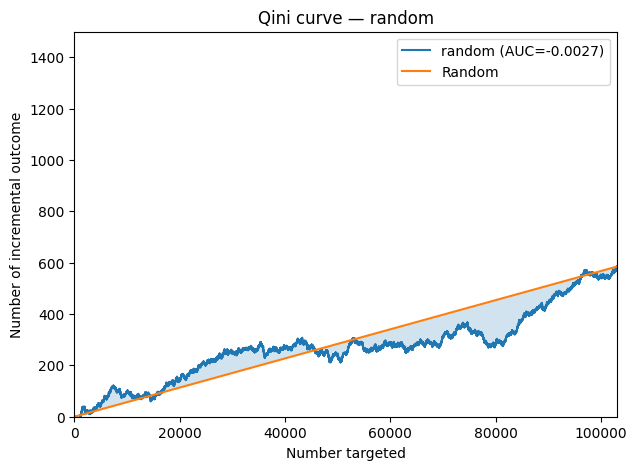

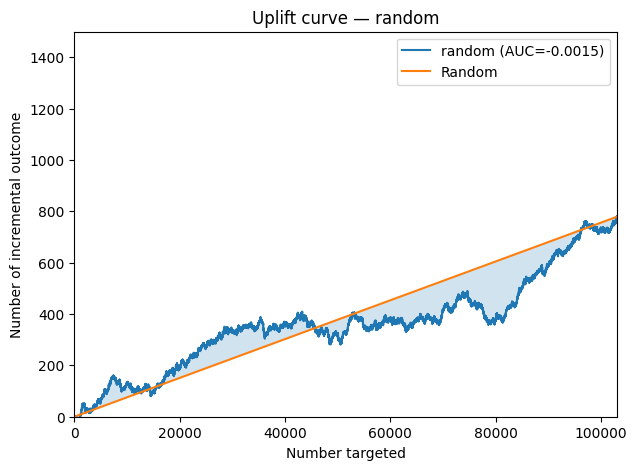

In [ ]:
model_name, model = "random", RandomUpliftModel(random_state=42)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### Response Model

Предсказываем вероятность целевого действия обычнычным классификатором, никак не учитываем treatment

Нужна как бейзлайн чтобы проверить, что treatment вообще на что-то влияет

Видим что уже можем получить uplift около 1% только на основе фичей


===== response_model =====


Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   0.01863
uplift@10:   0.02232
uplift@30:   0.01114
Qini AUC:    0.00944
Uplift AUC:  0.00513
profit@5:   -29280.00
profit@10:   -39590.69
profit@30:   -291595.60


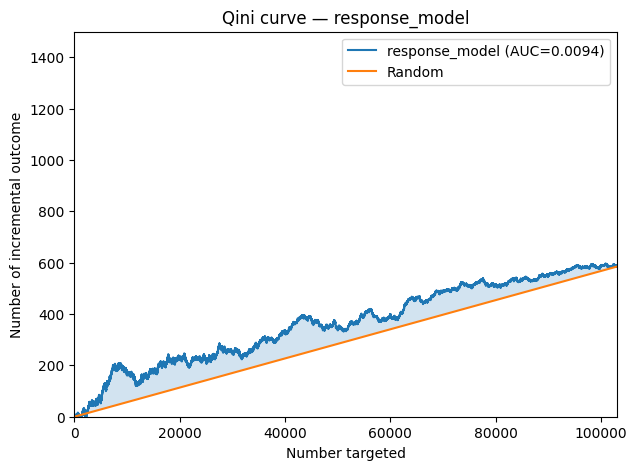

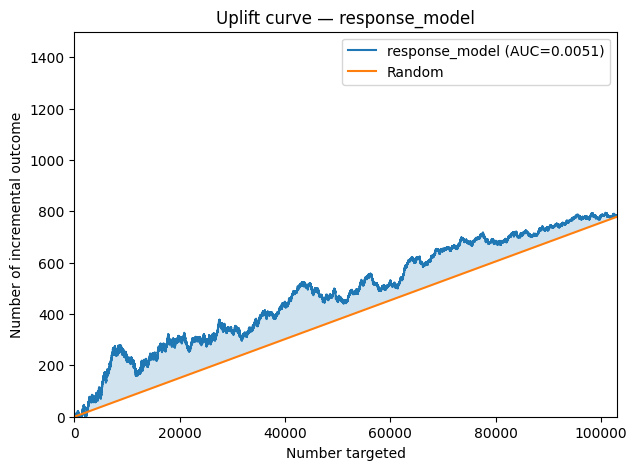

In [ ]:
model_name, model = "response_model", ResponseModel(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


## Базовые подходы

### S-Learner

Учим одну модель с Treatment как бинарная фича

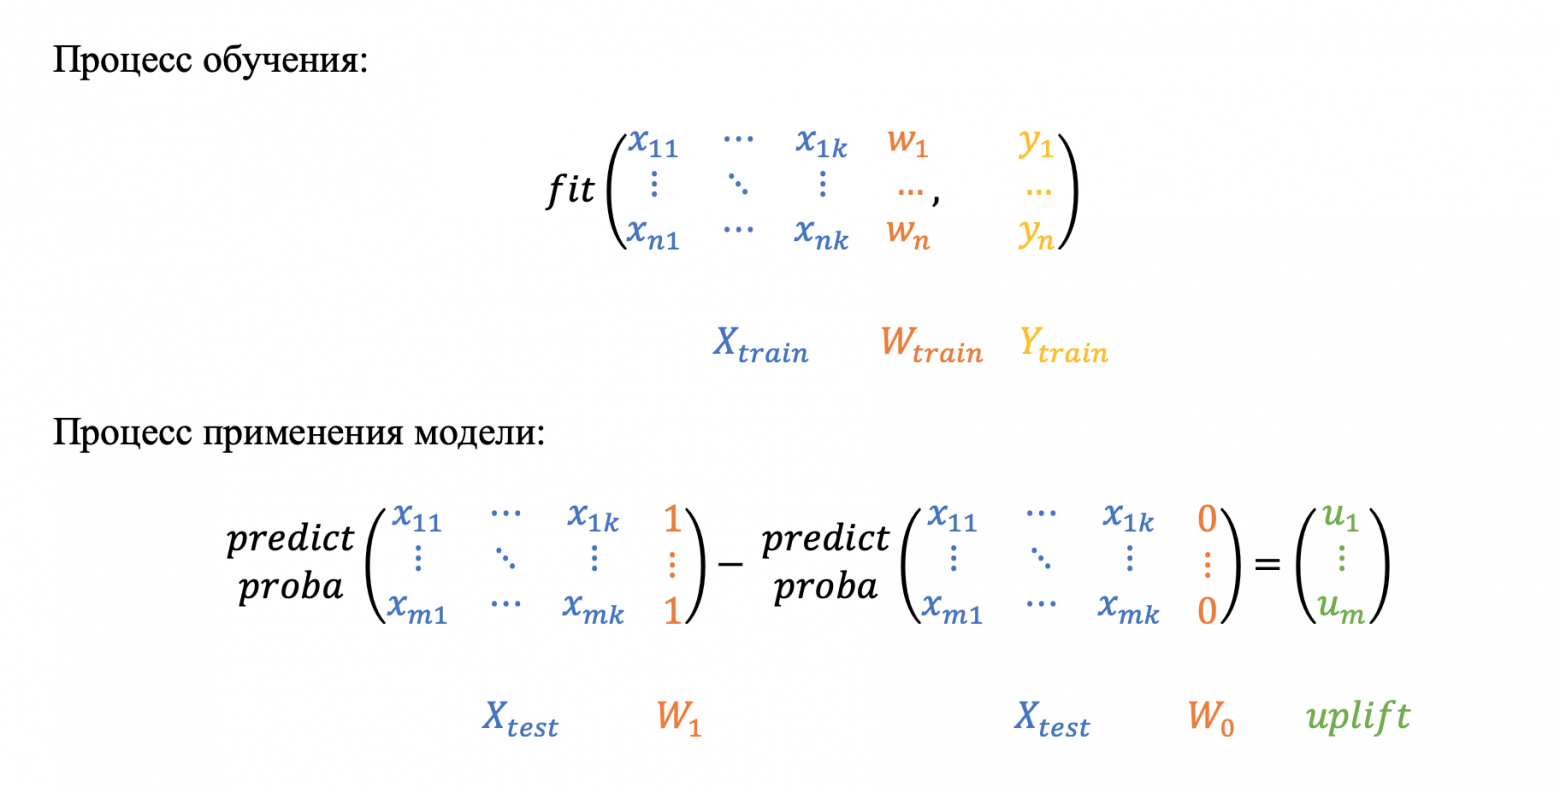

In [ ]:
class SLearner:
    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []
        self.model = make_cb_classifier()
        self.treatment_feature = "__treatment__"

    def _add_treatment(self, X, treatment_value):
        X_new = X.copy()
        X_new[self.treatment_feature] = treatment_value
        return X_new

    def fit(self, X, y, treatment):
        X_train = X.copy()
        X_train[self.treatment_feature] = treatment.values

        self.model.fit(
            X_train,
            y,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        X_treat = self._add_treatment(X, 1)
        X_control = self._add_treatment(X, 0)

        p_treat = self.model.predict_proba(X_treat)[:, 1]
        p_control = self.model.predict_proba(X_control)[:, 1]

        return p_treat - p_control


Результаты уже немного лучше, даже получилось выйти в прибыль на лучших 10%


===== s_learner =====


Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   0.02020
uplift@10:   0.03244
uplift@30:   0.01155
Qini AUC:    0.01903
Uplift AUC:  0.01037
profit@5:   -25243.40
profit@10:   12549.52
profit@30:   -285196.03


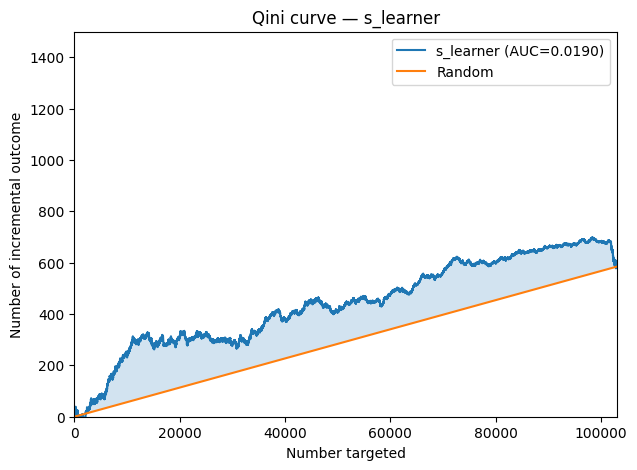

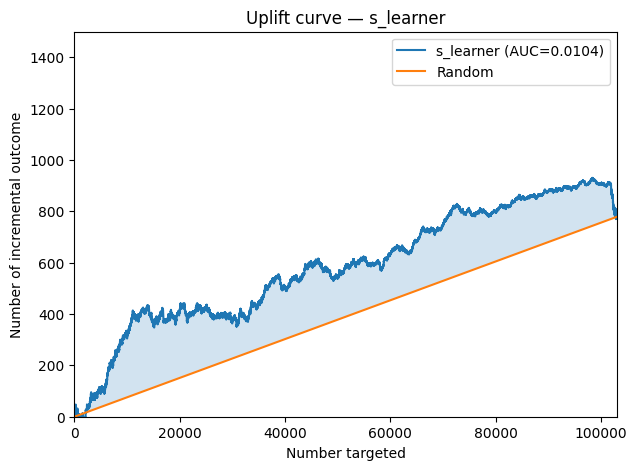

In [ ]:
model_name, model = "s_learner", SLearner(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### T-Learner

Учим две разные модели на Test и Control, далее каждой из них скорим выборку и считаем uplift как разность предсказаний

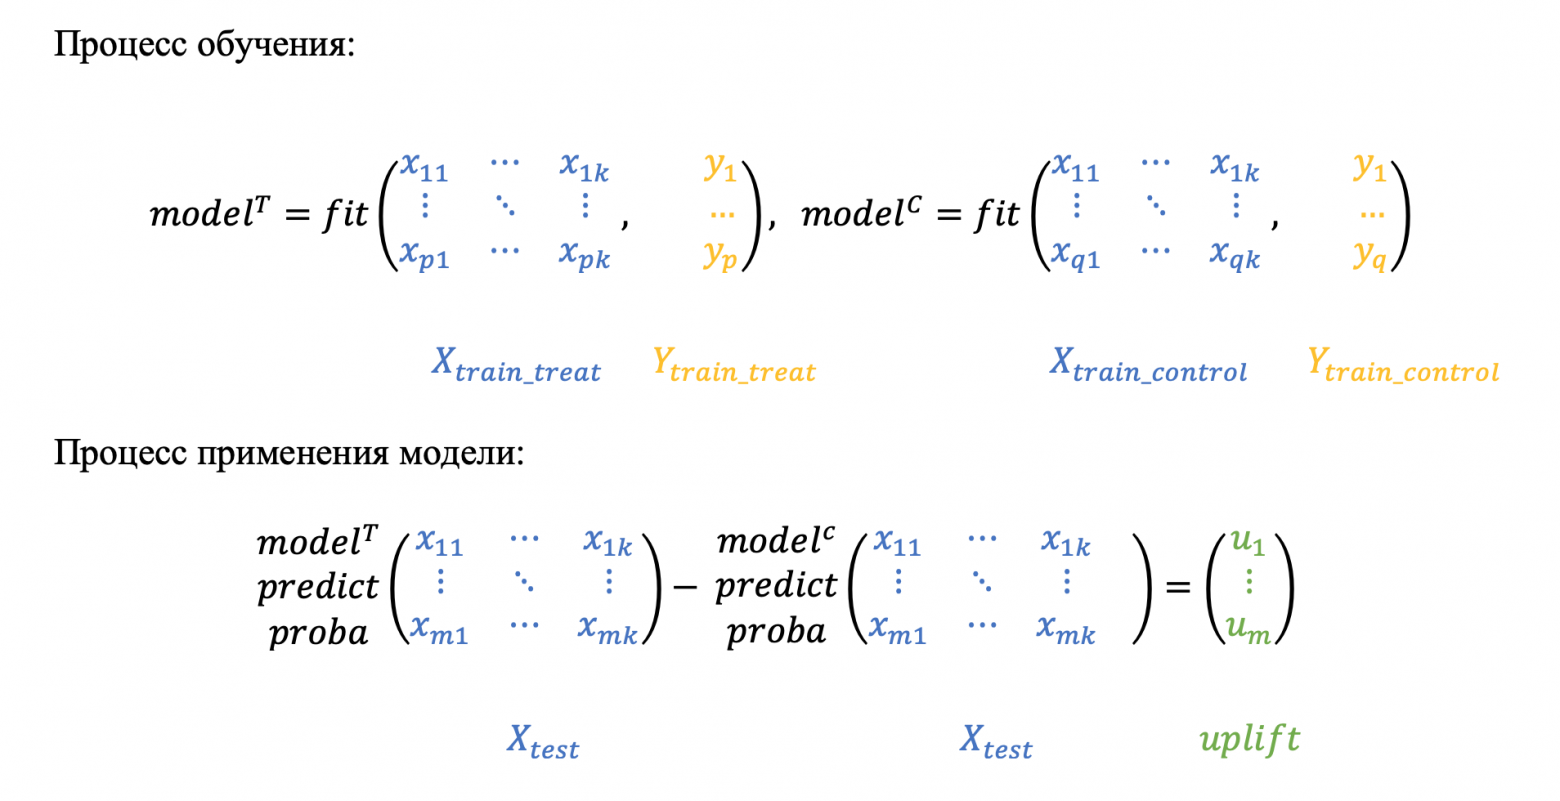

In [ ]:
class TLearner:
    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []
        self.model_treat = make_cb_classifier()
        self.model_control = make_cb_classifier()

    def fit(self, X, y, treatment):
        treatment = pd.Series(treatment, index=X.index)
        y = pd.Series(y, index=X.index)

        mask_t = treatment == 1
        mask_c = treatment == 0

        self.model_treat.fit(
            X.loc[mask_t],
            y.loc[mask_t],
            cat_features=self.cat_features
        )

        self.model_control.fit(
            X.loc[mask_c],
            y.loc[mask_c],
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        p_treat = self.model_treat.predict_proba(X)[:, 1]
        p_control = self.model_control.predict_proba(X)[:, 1]

        return p_treat - p_control


Видим что T-Learner хуже ранжирует верх и у него ошибка больше чем у S-Learner. Это может быть связано с:

- Обе модели учатся независимо и их ошибки суммируются

- Размер выборки для модели контроля недостаточно большой, чтобы модель на основе него хорошо предсказывала весь датасет


===== t_learner =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   0.00380
uplift@10:   0.00929
uplift@30:   0.01227
Qini AUC:    0.01323
Uplift AUC:  0.00720
profit@5:   -67495.82
profit@10:   -106703.54
profit@30:   -274012.41


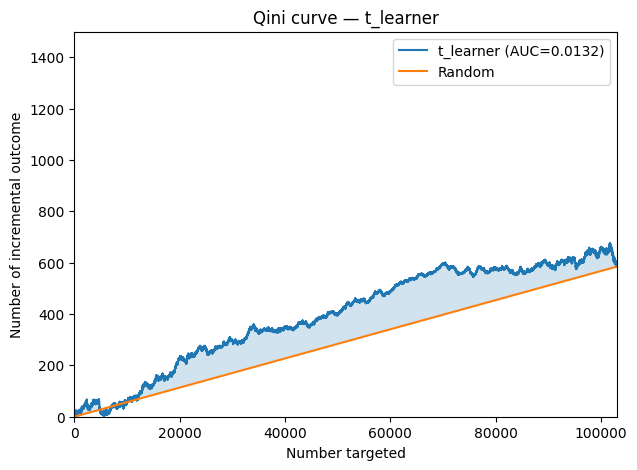

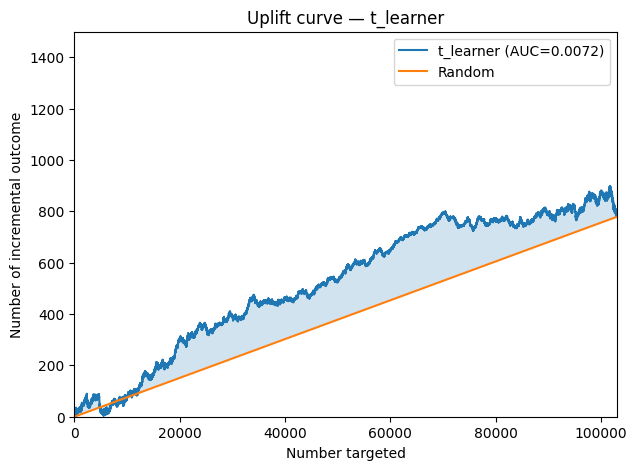

In [ ]:
model_name, model = "t_learner", TLearner(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### Class Transformation (Binary)

Создаем новый таргет следующим образом и учим классификатор на него

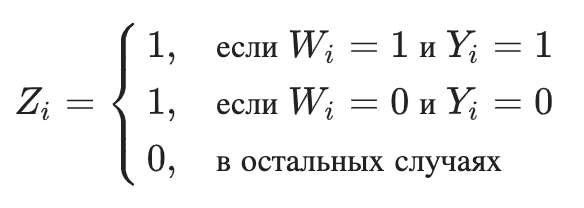

In [ ]:
class ClassTransformationModel:
    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []
        self.model = make_cb_classifier()

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index)
        treatment = pd.Series(treatment, index=X.index)

        z = (
            ((treatment == 1) & (y == 1)) |
            ((treatment == 0) & (y == 0))
        ).astype(int)

        p_treat = treatment.mean()

        sample_weight = np.where(
            treatment == 1,
            0.5 / p_treat,
            0.5 / (1 - p_treat)
        )

        self.model.fit(
            X,
            z,
            sample_weight=sample_weight,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        p_z = self.model.predict_proba(X)[:, 1]

        return 2 * p_z - 1


Результаты значительно выше предыдущих подходов. При этом стоит учесть, что в данном подходе для интерпретируемости предсказаний как uplift нужно соотношение test/control = 50/50, а у нас 75/25

- Тем не менее дисбаланс классов частично учитывался при пересчете sample_weight, чего не было в прошлых моделях

- Свели задачу к бинарной классификации для типа клиентов, больше всего влияющих на uplift (убеждаемый / не убеждаемый). При этом обучение происходит на всех данных (в отличие от T-Learner)

- Важно что выбранные метрики отражают качество ранжирования, а не точно предсказанный uplift. Поэтому модель могла хорошо отранжировать клиентов, несмотря на то что ее предикты - это не чистый uplift из за дисбаланса. Это нужно учитывать - модель используем для ранкинга

- У топ-5% ранжирование хуже чем при более крупном сегменте. Но на 10 и 30 процентах модель сильно лучше, из за чего и AUC у нее выше тк он считается по всем размерам сегментов


===== class_transformation =====


Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   -0.00670
uplift@10:   0.04625
uplift@30:   0.02768
Qini AUC:    0.03251
Uplift AUC:  0.01951
profit@5:   -94539.40
profit@10:   83731.05
profit@30:   -35883.09


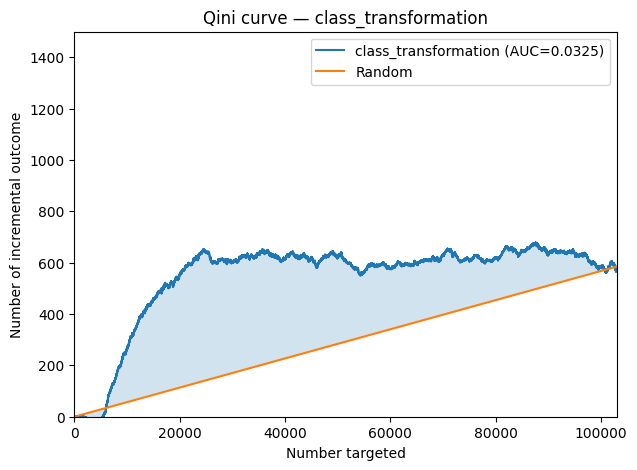

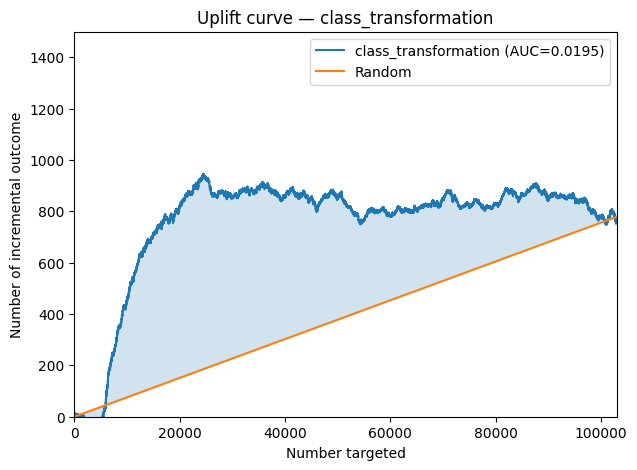

In [ ]:
model_name, model = "class_transformation", ClassTransformationModel(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


## Продвнутые подходы

### Transformed Outcome (Regression)

В этом подходе тоже делаем трансформацию классов, только с учетом реального соотношения test/control. Таргет уже не бинарная фича как в предыдущем подходе

$ Z_i = Y_i \frac{W_i - p}{p(1 - p)} $

In [ ]:
class TransformedOutcomeModel:
    def __init__(self, cat_features=None, clip_propensity=1e-3):
        self.cat_features = cat_features or []
        self.model = make_cb_regressor()
        self.clip_propensity = clip_propensity
        self.p_treat_ = None

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index).astype(float)
        treatment = pd.Series(treatment, index=X.index).astype(int)

        p_treat = treatment.mean()
        p_treat = np.clip(
            p_treat,
            self.clip_propensity,
            1 - self.clip_propensity
        )

        self.p_treat_ = p_treat

        z = y * (treatment - p_treat) / (p_treat * (1 - p_treat))

        self.model.fit(
            X,
            z,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        uplift_pred = self.model.predict(X)

        return np.clip(uplift_pred, -1, 1)


Тут уже была корректно учтена доля test/control, но модель сильно хуже. В частности это происходит из за:

- Более шумного таргета в задаче регрессии, при доле классов 75/20 получаем значения таргета от -4 до 1.33. При доле положительного таргета во всем датасете ~0.1, модель будет выдавать прогнозы ближе к 0

- В частности для метрик на основе ранжирования такой разброс плох. Даже если мы более точно оценили сам uplift


===== transformed_outcome =====
uplift@5:   0.01205
uplift@10:   0.00196
uplift@30:   0.00727
Qini AUC:    0.00050
Uplift AUC:  -0.00021
profit@5:   -46229.58
profit@10:   -144487.33
profit@30:   -351348.48


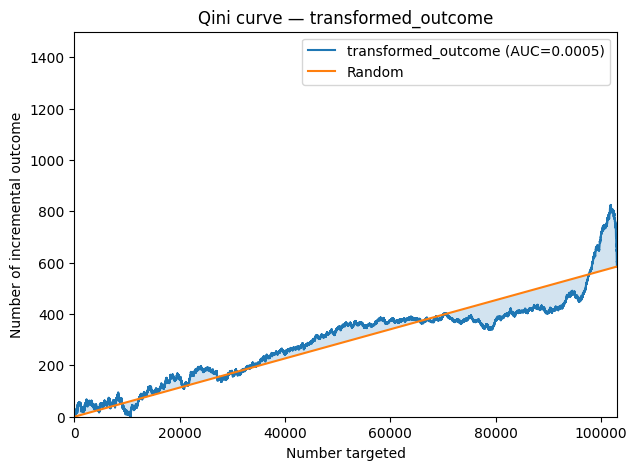

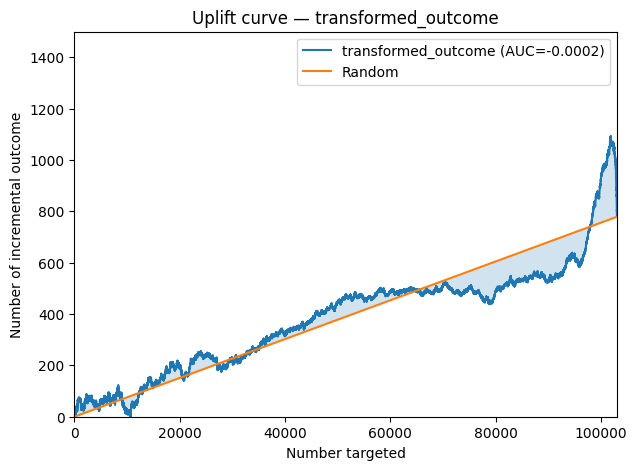

In [ ]:
model_name, model = "transformed_outcome", TransformedOutcomeModel(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### X-Learner

Обучаем две зависимые модели на test/control. Учим новые модели на основе ошибок предсказания модели в противоположной группе. То есть подход аналогичный T-Learner, но учим дополнительно модели хорошо предсказывать не только на test/control, но и на другом классе тоже

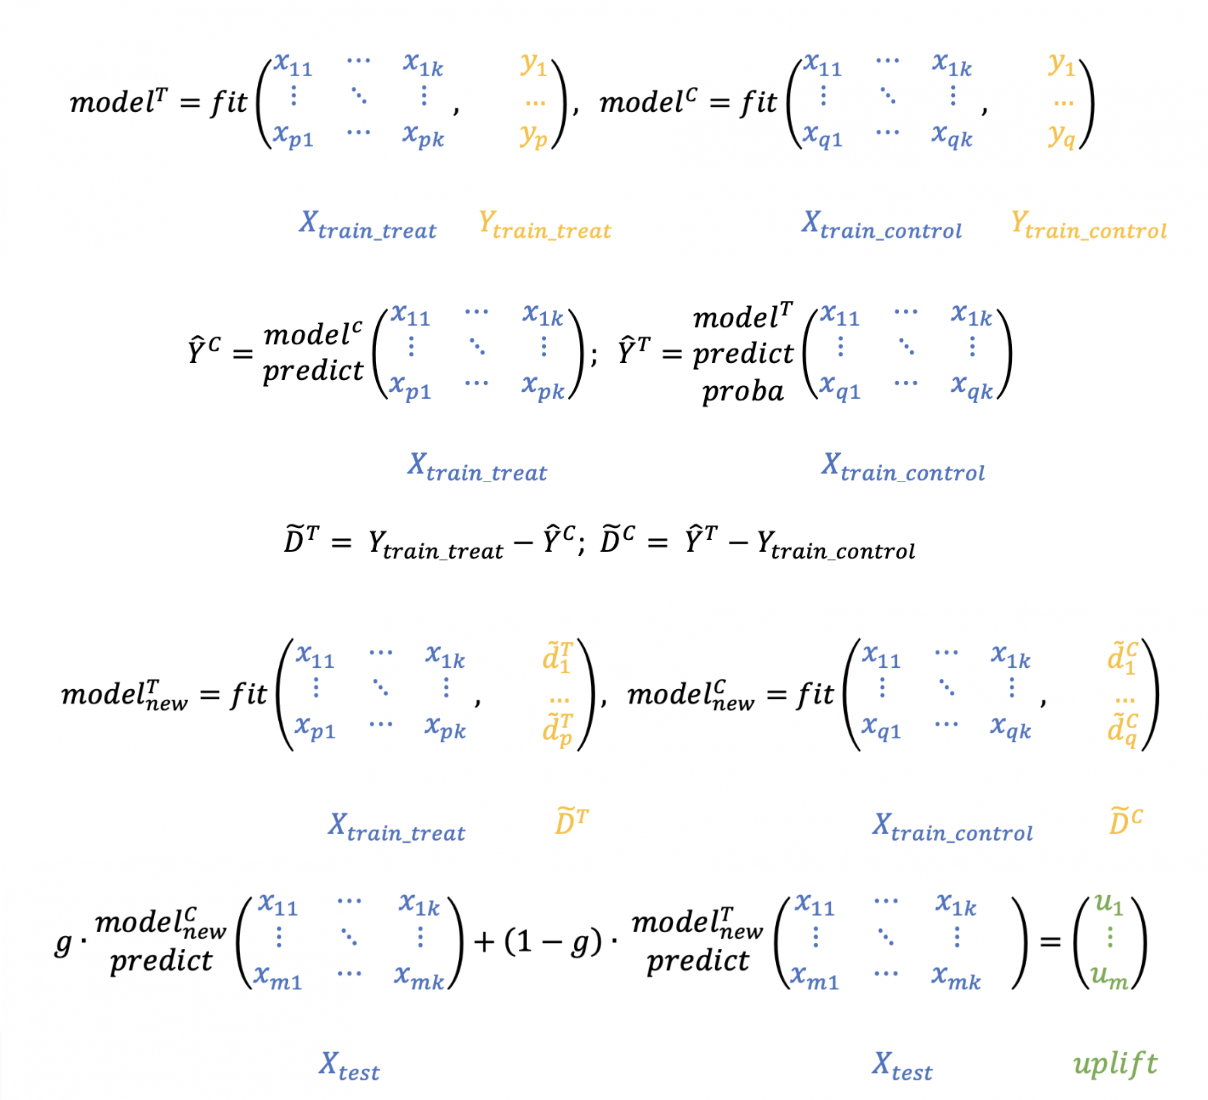



In [ ]:
class XLearner:
    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []

        self.model_treat = make_cb_classifier()
        self.model_control = make_cb_classifier()

        self.tau_treat_model = make_cb_regressor()
        self.tau_control_model = make_cb_regressor()

        self.propensity_ = None

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index)
        treatment = pd.Series(treatment, index=X.index)

        mask_t = treatment == 1
        mask_c = treatment == 0

        self.propensity_ = treatment.mean()

        self.model_treat.fit(
            X.loc[mask_t],
            y.loc[mask_t],
            cat_features=self.cat_features
        )

        self.model_control.fit(
            X.loc[mask_c],
            y.loc[mask_c],
            cat_features=self.cat_features
        )

        p_control_on_treat = self.model_control.predict_proba(X.loc[mask_t])[:, 1]
        p_treat_on_control = self.model_treat.predict_proba(X.loc[mask_c])[:, 1]

        d_treat = y.loc[mask_t] - p_control_on_treat
        d_control = p_treat_on_control - y.loc[mask_c]

        self.tau_treat_model.fit(
            X.loc[mask_t],
            d_treat,
            cat_features=self.cat_features
        )

        self.tau_control_model.fit(
            X.loc[mask_c],
            d_control,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        tau_treat = self.tau_treat_model.predict(X)
        tau_control = self.tau_control_model.predict(X)

        e = self.propensity_

        uplift = e * tau_control + (1 - e) * tau_treat

        return uplift


Результаты почти как у рандомной модели. Это может быть связано с:

- Pseudo-uplift на котором учим вторые модели мог быть слишком зашумлен из за низкого базового uplift по всему датасету (0.007) и большой ошибки моделей обученных на test/control (дизбаланс классов)

- В связи с маленькими по модулю значениями uplift (и предсказанных и реальных), модель учит разность между двумя близкими околонулевыми вероятностями, в дополнении с шумом это может не дать никакого эффекта, тк разница слишком мала


===== x_learner =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   0.01297
uplift@10:   -0.00184
uplift@30:   0.01194
Qini AUC:    0.00338
Uplift AUC:  0.00181
profit@5:   -43879.81
profit@10:   -164036.28
profit@30:   -279162.80


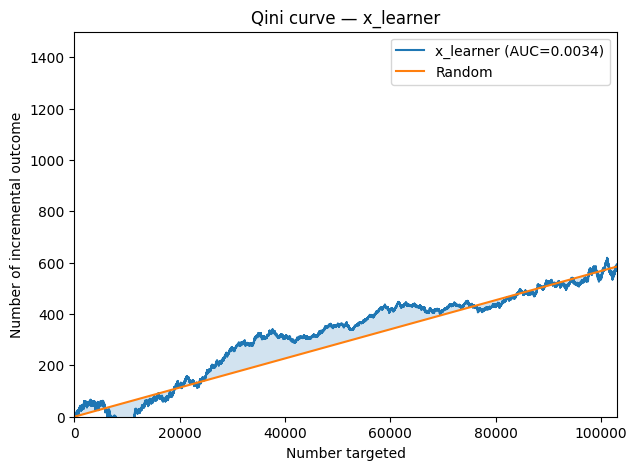

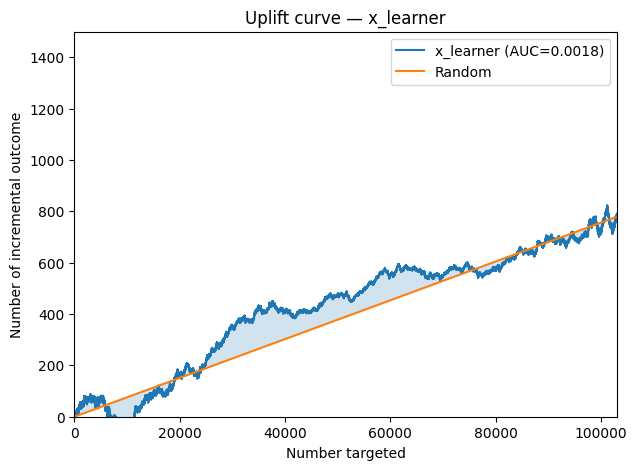

In [ ]:
model_name, model = "x_learner", XLearner(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### DR-Learner

Идея: используем T-Learner как основу, но при расчете uplift делаем поправку на ошибку с учетом баланса классов.

В T-Learner:

$uplift = Model^T (X) - Model^C (X)$

Добавляем поправку ошибки:

Для Test (Treatment = W = 1):

$W \frac{Y - Model^T (X)}{P(W=1 | X)}$

Для Control (Treatment = W = 0):

$(1-W) \frac{Y - Model^C (X)}{P(W=0 | X)}$

Итоговая формула:

$$ uplift = Model^T (X) - Model^C (X) + W \frac{Y - Model^T (X)}{P(W=1 | X)} - (1-W) \frac{Y - Model^C (X)}{P(W=0 | X)}$$

In [ ]:
class DRLearnerManual:

    def __init__(self, cat_features=None):
        self.cat_features = cat_features or []

        self.model_treat = make_cb_classifier()
        self.model_control = make_cb_classifier()
        self.final_model = make_cb_regressor()

        self.propensity_ = None

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index)
        treatment = pd.Series(treatment, index=X.index)

        mask_t = treatment == 1
        mask_c = treatment == 0

        e = treatment.mean()
        e = np.clip(e, 1e-3, 1 - 1e-3)
        self.propensity_ = e

        self.model_treat.fit(
            X.loc[mask_t],
            y.loc[mask_t],
            cat_features=self.cat_features
        )

        self.model_control.fit(
            X.loc[mask_c],
            y.loc[mask_c],
            cat_features=self.cat_features
        )

        m1 = self.model_treat.predict_proba(X)[:, 1]
        m0 = self.model_control.predict_proba(X)[:, 1]

        tau_dr = (
            m1 - m0
            + treatment * (y - m1) / e
            - (1 - treatment) * (y - m0) / (1 - e)
        )

        self.final_model.fit(
            X,
            tau_dr,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        return self.final_model.predict(X)


Получили лучший результат на топ-5% клиентов. Модель хорошо нашла узкий сегмент с очень высоким uplift. Но при увеличении размера сегмента качество падает


===== dr_learner =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


uplift@5:   0.04567
uplift@10:   0.01923
uplift@30:   0.01134
Qini AUC:    0.00834
Uplift AUC:  0.00453
profit@5:   40368.37
profit@10:   -55505.70
profit@30:   -288408.32


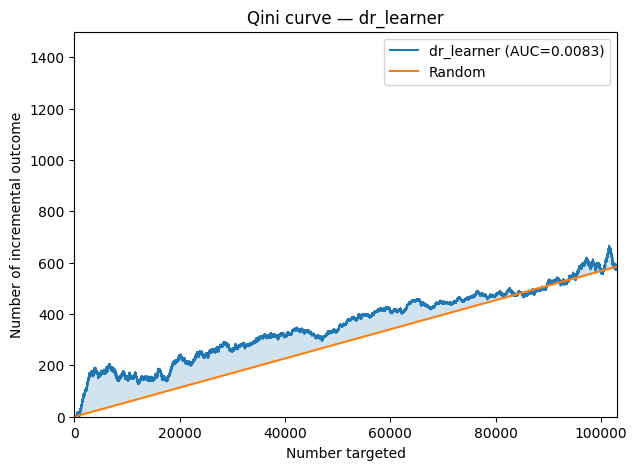

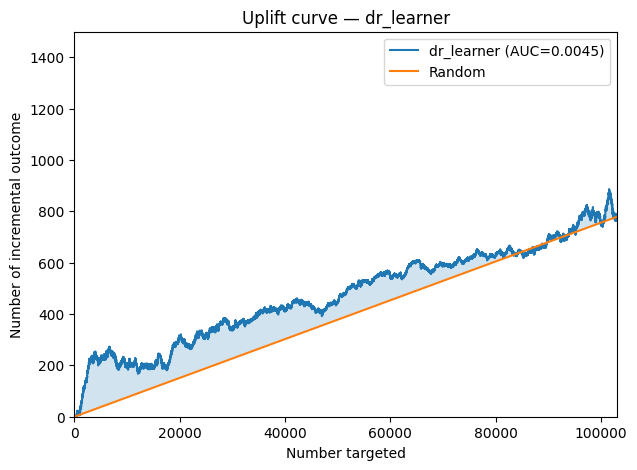

In [ ]:
model_name, model = "dr_learner", DRLearnerManual(cat_features=cat_features)

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### Uplift Random Forest

Тут мы учим классический random forest, только критерием разбиения в ноде выступает не энтропия, а uplift посчитанный на основе двух получившихся групп. Таким образом мы строим каждое дерево так, чтобы максимизировать uplift. При этом мы учитываем, чтобы в листе было больше определенного количества сэмплов

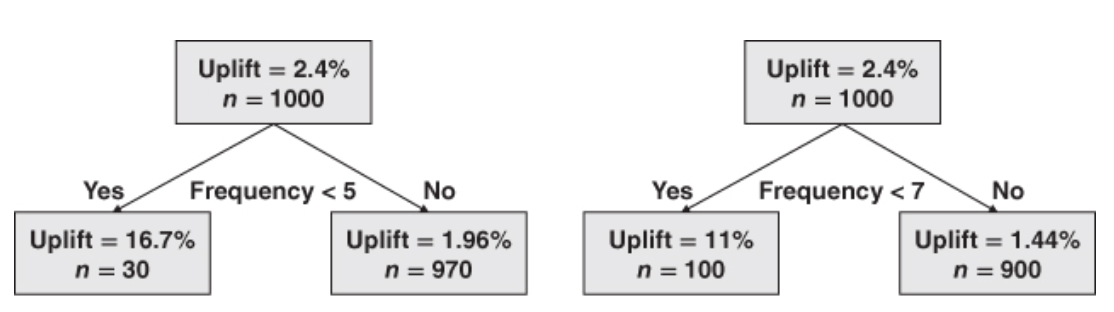

In [ ]:
class UpliftRandomForestWrapper:
    def __init__(self, random_state=RANDOM_STATE):
        from causalml.inference.tree import UpliftRandomForestClassifier

        self.model = UpliftRandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            min_samples_leaf=500,
            min_samples_treatment=100,
            control_name="control",
            random_state=random_state
        )

        self.imputer = SimpleImputer(strategy="median")

    def fit(self, X, y, treatment):
        X_imp = self.imputer.fit_transform(X)

        treatment_names = np.where(
            np.asarray(treatment) == 1,
            "treatment",
            "control"
        )

        self.model.fit(
            X=X_imp,
            treatment=treatment_names,
            y=np.asarray(y)
        )

        return self

    def predict_uplift(self, X):
        X_imp = self.imputer.transform(X)

        pred = self.model.predict(X_imp)

        pred = np.asarray(pred)

        if pred.ndim == 2:
            return pred[:, 0]

        return pred


В целом результаты лучше и стабильнее, чем при других подходах. При этом в качестве ранжирования все равно уступаем Class Transformation

- Тут мы строим одну модель на всех данных

- Оптимизируем uplift напрямую, а не через оценки

- Возможно при большем количестве деревьев можно было добиться лучшего качества, но для only-cpu обучения это уже слишком долго

Failed to import duecredit due to No module named 'duecredit'



===== uplift_random_forest =====
uplift@5:   0.03228
uplift@10:   0.02257
uplift@30:   0.02065
Qini AUC:    0.02355
Uplift AUC:  0.01314
profit@5:   5883.54
profit@10:   -38263.25
profit@30:   -144493.35


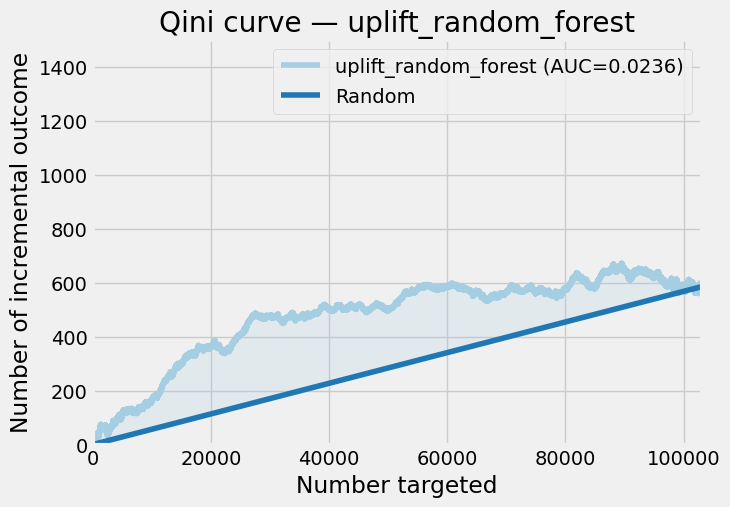

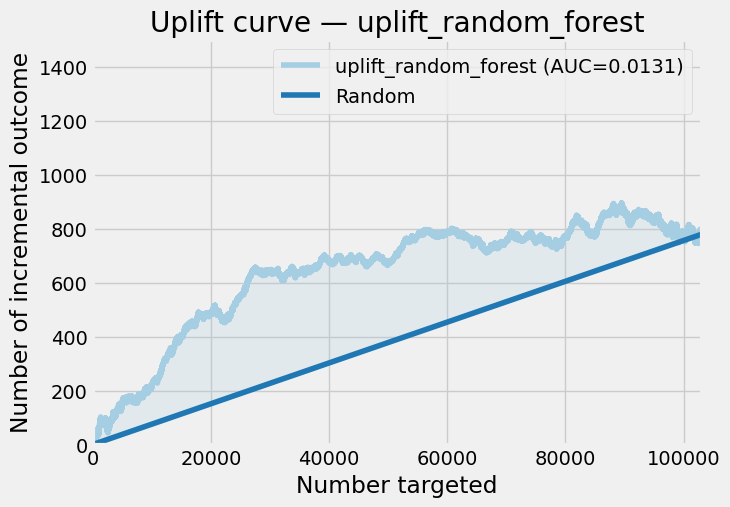

In [ ]:
model_name, model = "uplift_random_forest", UpliftRandomForestWrapper()

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


## Deep Learning подходы

In [ ]:
import copy
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def set_torch_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


In [ ]:
class MLPBackbone(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128), dropout=0.15):
        super().__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = hidden_dim

        self.net = nn.Sequential(*layers)
        self.output_dim = prev_dim

    def forward(self, x):
        return self.net(x)


In [ ]:
class BaseDeepUpliftModel:
    def __init__(
        self,
        hidden_dims=(512, 256, 128),
        dropout=0.15,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8192,
        epochs=30,
        patience=5,
        val_size=0.15,
        random_state=42,
        device=None,
        verbose=True
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.epochs = epochs
        self.patience = patience
        self.val_size = val_size
        self.random_state = random_state
        self.verbose = verbose

        if device is None:
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = device

        self.preprocessor = None
        self.model = None
        self.best_state_dict = None

    def _build_model(self, input_dim):
        raise NotImplementedError

    def _make_preprocessor(self, X):
        numeric_features = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
        categorical_features = [
            col for col in X.columns
            if col not in numeric_features
        ]

        numeric_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]
        )

        categorical_transformer = Pipeline(
            steps=[
                ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
            ]
        )

        transformers = []

        if len(numeric_features) > 0:
            transformers.append(("num", numeric_transformer, numeric_features))

        if len(categorical_features) > 0:
            transformers.append(("cat", categorical_transformer, categorical_features))

        return ColumnTransformer(
            transformers=transformers,
            remainder="drop",
            verbose_feature_names_out=False
        )

    def _prepare_data(self, X, fit_preprocessor=False):
        if fit_preprocessor:
            self.preprocessor = self._make_preprocessor(X)
            X_prepared = self.preprocessor.fit_transform(X)
        else:
            X_prepared = self.preprocessor.transform(X)

        if hasattr(X_prepared, "toarray"):
            X_prepared = X_prepared.toarray()

        return X_prepared.astype(np.float32)

    def _make_loader(self, X, y, treatment, shuffle=True):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(np.asarray(y), dtype=torch.float32)
        t_tensor = torch.tensor(np.asarray(treatment), dtype=torch.float32)

        dataset = TensorDataset(X_tensor, y_tensor, t_tensor)

        return DataLoader(
            dataset,
            batch_size=self.batch_size,
            shuffle=shuffle,
            num_workers=0,
            pin_memory=True
        )

    def _compute_loss(self, outputs, y, treatment):
        raise NotImplementedError

    def _train_one_epoch(self, train_loader, optimizer):
        self.model.train()

        losses = []

        for X_batch, y_batch, t_batch in train_loader:
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
            t_batch = t_batch.to(self.device, non_blocking=True)

            optimizer.zero_grad()

            outputs = self.model(X_batch)
            loss = self._compute_loss(outputs, y_batch, t_batch)

            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        return float(np.mean(losses))

    @torch.no_grad()
    def _evaluate_loss(self, valid_loader):
        self.model.eval()

        losses = []

        for X_batch, y_batch, t_batch in valid_loader:
            X_batch = X_batch.to(self.device, non_blocking=True)
            y_batch = y_batch.to(self.device, non_blocking=True)
            t_batch = t_batch.to(self.device, non_blocking=True)

            outputs = self.model(X_batch)
            loss = self._compute_loss(outputs, y_batch, t_batch)

            losses.append(loss.item())

        return float(np.mean(losses))

    def fit(self, X, y, treatment):
        set_torch_seed(self.random_state)

        X = X.copy()
        y = pd.Series(y).astype(int).reset_index(drop=True)
        treatment = pd.Series(treatment).astype(int).reset_index(drop=True)

        X = X.reset_index(drop=True)

        if self.val_size and self.val_size > 0:
            strata = treatment.astype(str) + "_" + y.astype(str)

            X_tr, X_val, y_tr, y_val, t_tr, t_val = train_test_split(
                X,
                y,
                treatment,
                test_size=self.val_size,
                random_state=self.random_state,
                stratify=strata
            )
        else:
            X_tr, y_tr, t_tr = X, y, treatment
            X_val, y_val, t_val = None, None, None

        X_tr_np = self._prepare_data(X_tr, fit_preprocessor=True)

        if X_val is not None:
            X_val_np = self._prepare_data(X_val, fit_preprocessor=False)
        else:
            X_val_np = None

        input_dim = X_tr_np.shape[1]

        self.model = self._build_model(input_dim).to(self.device)

        train_loader = self._make_loader(
            X_tr_np,
            y_tr.values,
            t_tr.values,
            shuffle=True
        )

        if X_val_np is not None:
            valid_loader = self._make_loader(
                X_val_np,
                y_val.values,
                t_val.values,
                shuffle=False
            )
        else:
            valid_loader = None

        optimizer = torch.optim.AdamW(
            self.model.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )

        best_valid_loss = np.inf
        bad_epochs = 0

        for epoch in range(1, self.epochs + 1):
            train_loss = self._train_one_epoch(train_loader, optimizer)

            if valid_loader is not None:
                valid_loss = self._evaluate_loss(valid_loader)
                current_score = valid_loss

                if self.verbose:
                    print(
                        f"Epoch {epoch:03d} | "
                        f"train_loss={train_loss:.5f} | "
                        f"valid_loss={valid_loss:.5f}"
                    )

                if current_score < best_valid_loss:
                    best_valid_loss = current_score
                    bad_epochs = 0
                    self.best_state_dict = copy.deepcopy(self.model.state_dict())
                else:
                    bad_epochs += 1

                if bad_epochs >= self.patience:
                    if self.verbose:
                        print(f"Early stopping at epoch {epoch}")
                    break

            else:
                if self.verbose:
                    print(f"Epoch {epoch:03d} | train_loss={train_loss:.5f}")

        if self.best_state_dict is not None:
            self.model.load_state_dict(self.best_state_dict)

        return self

    @torch.no_grad()
    def predict_uplift(self, X):
        self.model.eval()

        X = X.copy().reset_index(drop=True)
        X_np = self._prepare_data(X, fit_preprocessor=False)

        X_tensor = torch.tensor(X_np, dtype=torch.float32)
        loader = DataLoader(
            TensorDataset(X_tensor),
            batch_size=self.batch_size,
            shuffle=False,
            num_workers=0,
            pin_memory=True
        )

        preds = []

        for (X_batch,) in loader:
            X_batch = X_batch.to(self.device, non_blocking=True)

            outputs = self.model(X_batch)

            p0 = torch.sigmoid(outputs["y0_logit"])
            p1 = torch.sigmoid(outputs["y1_logit"])

            uplift = p1 - p0

            preds.append(uplift.detach().cpu().numpy())

        return np.concatenate(preds)


### TARNet

Первые слои нейросети учим на всех данных и на фичах из X. На третьем слое добавляем Treatment-фичу и для Test/Control дальше по отдельности используются свои подслои

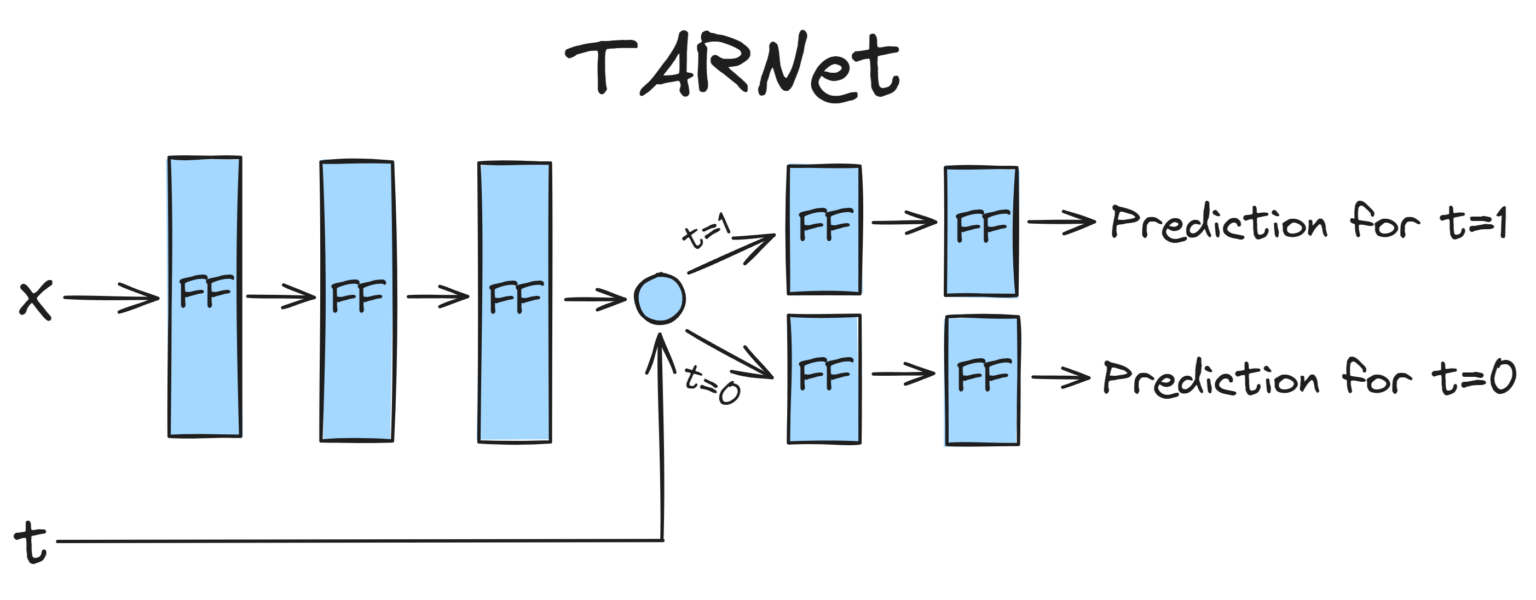

In [ ]:
class TARNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128), dropout=0.15):
        super().__init__()

        self.backbone = MLPBackbone(
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            dropout=dropout
        )

        rep_dim = self.backbone.output_dim

        self.head_control = nn.Sequential(
            nn.Linear(rep_dim, rep_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rep_dim // 2, 1)
        )

        self.head_treat = nn.Sequential(
            nn.Linear(rep_dim, rep_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rep_dim // 2, 1)
        )

    def forward(self, x):
        representation = self.backbone(x)
        y0_logit = self.head_control(representation).squeeze(1)
        y1_logit = self.head_treat(representation).squeeze(1)

        return {
            "representation": representation,
            "y0_logit": y0_logit,
            "y1_logit": y1_logit
        }

class TARNetUpliftModel(BaseDeepUpliftModel):
    def _build_model(self, input_dim):
        return TARNet(
            input_dim=input_dim,
            hidden_dims=self.hidden_dims,
            dropout=self.dropout
        )

    def _compute_loss(self, outputs, y, treatment):
        y0_logit = outputs["y0_logit"]
        y1_logit = outputs["y1_logit"]

        factual_logit = torch.where(
            treatment == 1,
            y1_logit,
            y0_logit
        )

        loss = nn.functional.binary_cross_entropy_with_logits(
            factual_logit,
            y
        )

        return loss


Не получили сильного прироста по сравнению с S-Learner


===== tarnet =====
Epoch 001 | train_loss=0.33909 | valid_loss=0.28650
Epoch 002 | train_loss=0.28602 | valid_loss=0.28594
Epoch 003 | train_loss=0.28425 | valid_loss=0.28503
Epoch 004 | train_loss=0.28335 | valid_loss=0.28447
Epoch 005 | train_loss=0.28170 | valid_loss=0.28477
Epoch 006 | train_loss=0.28078 | valid_loss=0.28518
Epoch 007 | train_loss=0.27969 | valid_loss=0.28547
Epoch 008 | train_loss=0.27827 | valid_loss=0.28485
Epoch 009 | train_loss=0.27728 | valid_loss=0.28612
Early stopping at epoch 9
uplift@5:   0.00566
uplift@10:   0.00761
uplift@30:   0.01302
Qini AUC:    0.01168
Uplift AUC:  0.00644
profit@5:   -62704.32
profit@10:   -115343.73
profit@30:   -262461.79


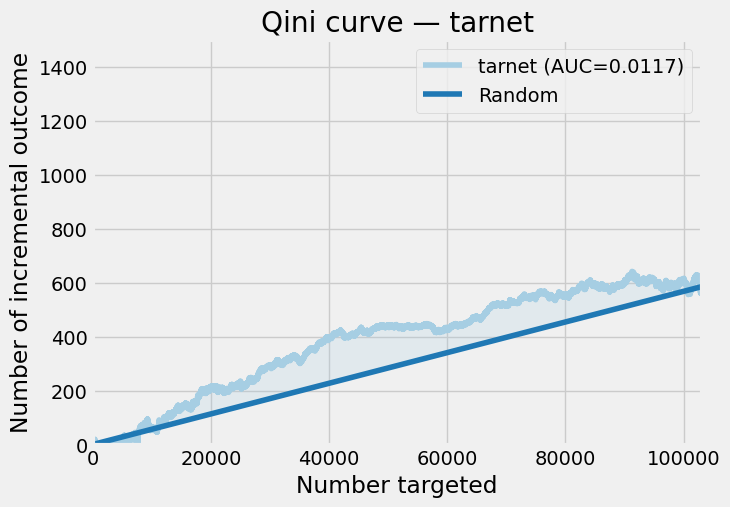

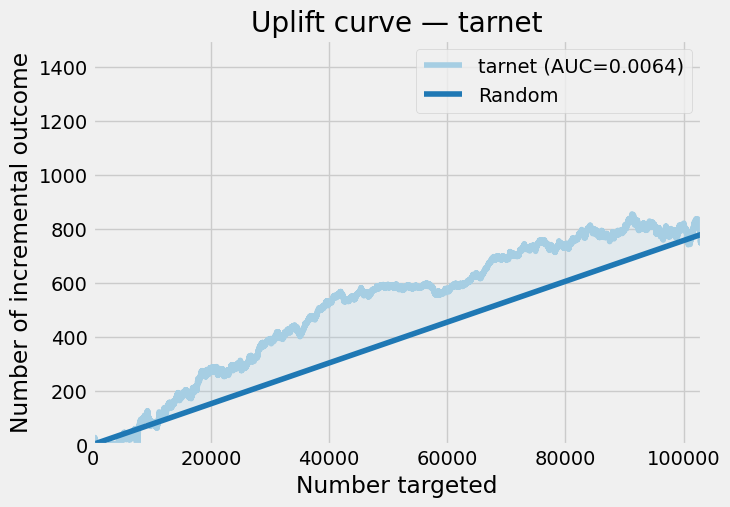

In [ ]:
model_name, model = "tarnet", TARNetUpliftModel(
        hidden_dims=(512, 256, 128),
        dropout=0.15,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8192,
        epochs=30,
        patience=5,
        val_size=0.15,
        random_state=42,
        verbose=True
    )

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### CFRNet c MMD Loss

CFRNet - модификация TARNet. Идея та же, только мы хотим, чтобы модель не просто учила различия между Test/Control, а оценивала влияние Treatment-а. Следовательно мы хотим, чтобы модель выучила скрытое представление, в котором Test и Control были бы похожи. Поэтому мы дополнительно штрафуем модель за различия между Test и Control

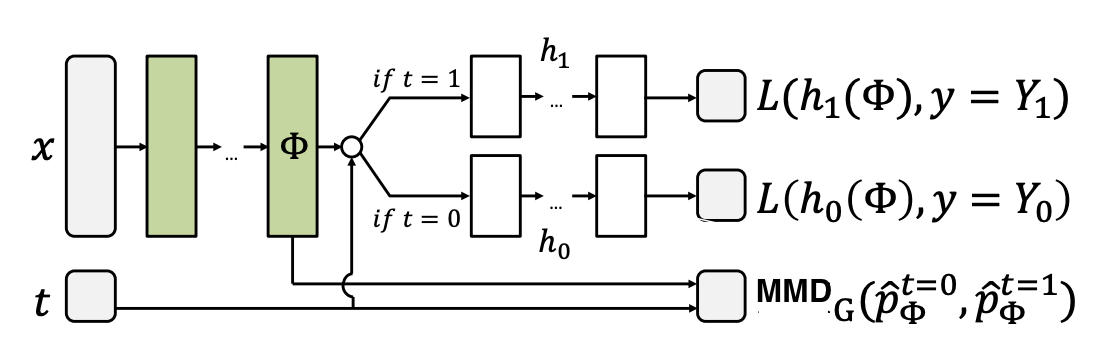

Как штрафуем? Введем дополнительный MMD Loss

$$ MMD^2 = mean( K(Test, Test)) + mean( K(Control, Control)) - 2 \cdot mean( K(Test, Control))$$

$K(a,b)$ - мера схожести двух объектов, в данном случае это RBF-ядро

$$ K(a,b) = e^{- \frac{||a-b||^2 }{2 \sigma^2}} $$

In [ ]:
def rbf_mmd_loss(x_treat, x_control, sigmas=(1.0, 2.0, 5.0, 10.0)):
    if len(x_treat) < 2 or len(x_control) < 2:
        return torch.tensor(0.0, device=x_treat.device)

    xx = torch.cdist(x_treat, x_treat, p=2) ** 2
    yy = torch.cdist(x_control, x_control, p=2) ** 2
    xy = torch.cdist(x_treat, x_control, p=2) ** 2

    loss = 0.0

    for sigma in sigmas:
        gamma = 1.0 / (2.0 * sigma ** 2)

        k_xx = torch.exp(-gamma * xx).mean()
        k_yy = torch.exp(-gamma * yy).mean()
        k_xy = torch.exp(-gamma * xy).mean()

        loss = loss + k_xx + k_yy - 2.0 * k_xy

    return loss / len(sigmas)


def sample_for_mmd(representation, treatment, max_samples=512):
    mask_t = treatment == 1
    mask_c = treatment == 0

    rep_t = representation[mask_t]
    rep_c = representation[mask_c]

    if len(rep_t) > max_samples:
        idx = torch.randperm(len(rep_t), device=representation.device)[:max_samples]
        rep_t = rep_t[idx]

    if len(rep_c) > max_samples:
        idx = torch.randperm(len(rep_c), device=representation.device)[:max_samples]
        rep_c = rep_c[idx]

    return rep_t, rep_c


In [ ]:
class CFRNetMMDUpliftModel(BaseDeepUpliftModel):
    def __init__(
        self,
        mmd_weight=0.1,
        mmd_sample_size=512,
        mmd_sigmas=(1.0, 2.0, 5.0, 10.0),
        **kwargs
    ):
        super().__init__(**kwargs)

        self.mmd_weight = mmd_weight
        self.mmd_sample_size = mmd_sample_size
        self.mmd_sigmas = mmd_sigmas

    def _build_model(self, input_dim):
        return TARNet(
            input_dim=input_dim,
            hidden_dims=self.hidden_dims,
            dropout=self.dropout
        )

    def _compute_loss(self, outputs, y, treatment):
        y0_logit = outputs["y0_logit"]
        y1_logit = outputs["y1_logit"]
        representation = outputs["representation"]

        factual_logit = torch.where(
            treatment == 1,
            y1_logit,
            y0_logit
        )

        outcome_loss = nn.functional.binary_cross_entropy_with_logits(
            factual_logit,
            y
        )

        rep_t, rep_c = sample_for_mmd(
            representation=representation,
            treatment=treatment,
            max_samples=self.mmd_sample_size
        )

        mmd_loss = rbf_mmd_loss(
            rep_t,
            rep_c,
            sigmas=self.mmd_sigmas
        )

        return outcome_loss + self.mmd_weight * mmd_loss


Подход оказался более эффективным. Все еще не такие высокие uplift-ы как у Class Transformation, но выше чем у других моделей и более стабилен при разных top-K. Модель непосредственно учила влияние Treatment-а, это дало прирост к качеству


===== cfrnet_mmd =====
Epoch 001 | train_loss=0.33933 | valid_loss=0.28699
Epoch 002 | train_loss=0.28662 | valid_loss=0.28578
Epoch 003 | train_loss=0.28464 | valid_loss=0.28508
Epoch 004 | train_loss=0.28352 | valid_loss=0.28498
Epoch 005 | train_loss=0.28213 | valid_loss=0.28511
Epoch 006 | train_loss=0.28077 | valid_loss=0.28559
Epoch 007 | train_loss=0.27995 | valid_loss=0.28595
Epoch 008 | train_loss=0.27831 | valid_loss=0.28567
Epoch 009 | train_loss=0.27708 | valid_loss=0.28642
Early stopping at epoch 9
uplift@5:   0.01435
uplift@10:   0.02486
uplift@30:   0.01580
Qini AUC:    0.02453
Uplift AUC:  0.01345
profit@5:   -40320.46
profit@10:   -26492.34
profit@30:   -219540.80


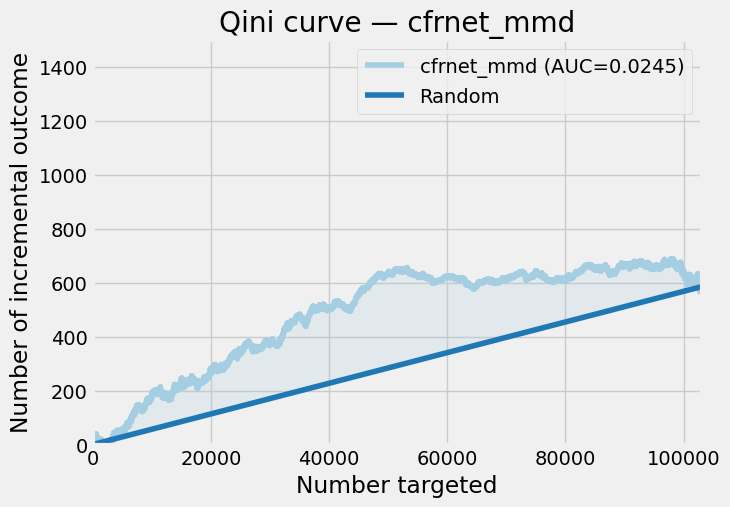

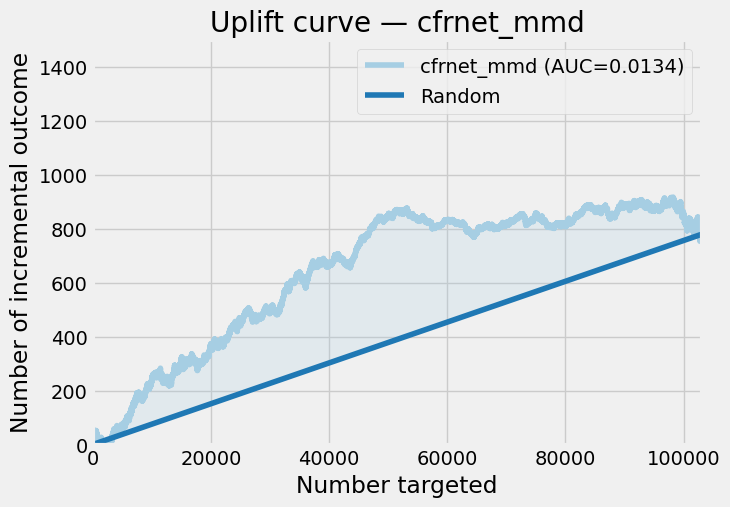

In [ ]:
model_name, model = "cfrnet_mmd", CFRNetMMDUpliftModel(
        hidden_dims=(512, 256, 128),
        dropout=0.15,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8192,
        epochs=30,
        patience=5,
        val_size=0.15,
        random_state=42,
        verbose=True
    )

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


### DragonNet

Подход наследуется от TARNet, только теперь добавляется третья голова, предсказывающая propensity (вероятность быть отнесенным к Treatment, она же использовалась в DR-Learner)

Модель дополнительно учится понимать, насколько клиент похож на тех, кто попал в Test, какие признаки связаны с фактом получения Treatment. Это может быть полезно при дизбалансе классов или различиях в Test/Control.

К обычному Loss теперь добавлется Propensity Loss, как раз отвечающий за корректное предсказание propensity

И отдельно добавляется Targeted Regularization - поправка к предсказаниям модели с учетом предсказанной propensity

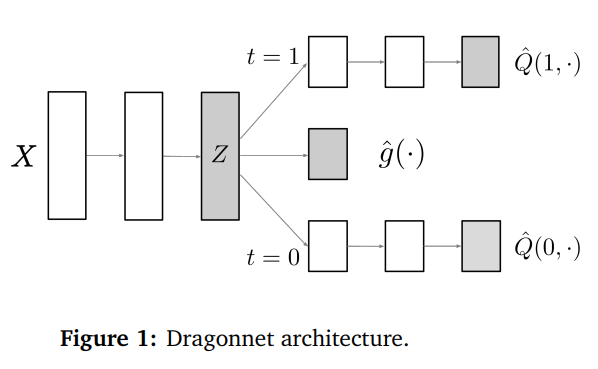

In [ ]:
class DragonNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=(512, 256, 128), dropout=0.15):
        super().__init__()

        self.backbone = MLPBackbone(
            input_dim=input_dim,
            hidden_dims=hidden_dims,
            dropout=dropout
        )

        rep_dim = self.backbone.output_dim

        self.head_control = nn.Sequential(
            nn.Linear(rep_dim, rep_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rep_dim // 2, 1)
        )

        self.head_treat = nn.Sequential(
            nn.Linear(rep_dim, rep_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rep_dim // 2, 1)
        )

        self.head_propensity = nn.Sequential(
            nn.Linear(rep_dim, rep_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(rep_dim // 2, 1)
        )

        self.epsilon = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        representation = self.backbone(x)

        y0_logit = self.head_control(representation).squeeze(1)
        y1_logit = self.head_treat(representation).squeeze(1)
        treatment_logit = self.head_propensity(representation).squeeze(1)

        return {
            "representation": representation,
            "y0_logit": y0_logit,
            "y1_logit": y1_logit,
            "treatment_logit": treatment_logit,
            "epsilon": self.epsilon
        }

class DragonNetUpliftModel(BaseDeepUpliftModel):
    def __init__(
        self,
        propensity_weight=0.1,
        targeted_reg_weight=0.1,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.propensity_weight = propensity_weight
        self.targeted_reg_weight = targeted_reg_weight

    def _build_model(self, input_dim):
        return DragonNet(
            input_dim=input_dim,
            hidden_dims=self.hidden_dims,
            dropout=self.dropout
        )

    def _compute_loss(self, outputs, y, treatment):
        y0_logit = outputs["y0_logit"]
        y1_logit = outputs["y1_logit"]
        treatment_logit = outputs["treatment_logit"]
        epsilon = outputs["epsilon"]

        factual_logit = torch.where(
            treatment == 1,
            y1_logit,
            y0_logit
        )

        outcome_loss = nn.functional.binary_cross_entropy_with_logits(
            factual_logit,
            y
        )

        propensity_loss = nn.functional.binary_cross_entropy_with_logits(
            treatment_logit,
            treatment
        )

        p0 = torch.sigmoid(y0_logit)
        p1 = torch.sigmoid(y1_logit)
        e = torch.sigmoid(treatment_logit).clamp(1e-3, 1 - 1e-3)

        q_factual = torch.where(
            treatment == 1,
            p1,
            p0
        )

        h = treatment / e - (1.0 - treatment) / (1.0 - e)

        q_targeted = q_factual + epsilon * h
        q_targeted = q_targeted.clamp(1e-5, 1 - 1e-5)

        targeted_loss = nn.functional.binary_cross_entropy(
            q_targeted,
            y
        )

        loss = (
            outcome_loss
            + self.propensity_weight * propensity_loss
            + self.targeted_reg_weight * targeted_loss
        )

        return loss


Прироста в качестве не дало. В целом константная оценка propensity=0.75 давала такой же результат, так как сильных различий в признаках у Test и Control не было, следовательно обучение отдельной головы под нахождение этой разности тут не дало эффекта


===== dragonnet =====
Epoch 001 | train_loss=0.43018 | valid_loss=0.37222
Epoch 002 | train_loss=0.37110 | valid_loss=0.37005
Epoch 003 | train_loss=0.36899 | valid_loss=0.36971
Epoch 004 | train_loss=0.36744 | valid_loss=0.36897
Epoch 005 | train_loss=0.36596 | valid_loss=0.36891
Epoch 006 | train_loss=0.36424 | valid_loss=0.36848
Epoch 007 | train_loss=0.36263 | valid_loss=0.36890
Epoch 008 | train_loss=0.36144 | valid_loss=0.36920
Epoch 009 | train_loss=0.36011 | valid_loss=0.36918
Epoch 010 | train_loss=0.35861 | valid_loss=0.37062
Epoch 011 | train_loss=0.35651 | valid_loss=0.37112
Early stopping at epoch 11
uplift@5:   0.02097
uplift@10:   0.02186
uplift@30:   0.01211
Qini AUC:    0.01073
Uplift AUC:  0.00601
profit@5:   -23271.61
profit@10:   -41935.13
profit@30:   -276481.08


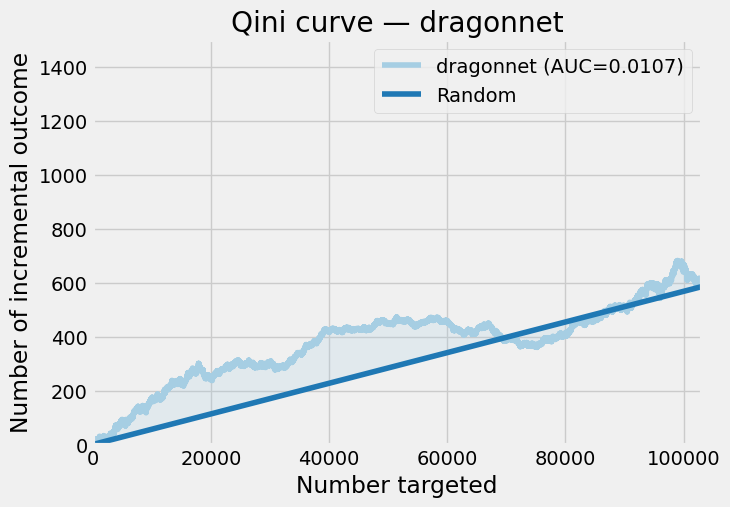

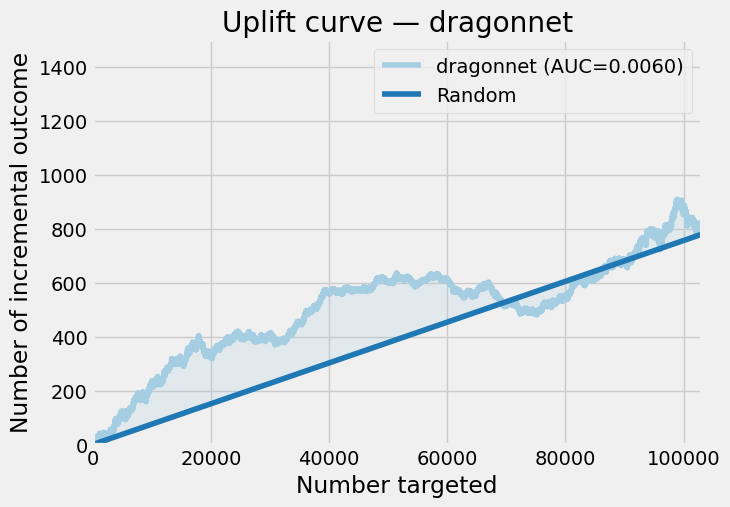

In [ ]:
model_name, model = "dragonnet", DragonNetUpliftModel(
        hidden_dims=(512, 256, 128),
        dropout=0.15,
        lr=1e-3,
        weight_decay=1e-4,
        batch_size=8192,
        epochs=30,
        patience=5,
        val_size=0.15,
        random_state=42,
        verbose=True
    )

results[model_name] = test_uplift_model(
        model_name=model_name,
        model=model,
        X_train=X_train,
        y_train=y_train,
        treatment_train=treatment_train,
        X_test=X_test,
        y_test=y_test,
        treatment_test=treatment_test,
        plot=True
    )


## Результаты

| **model**              | **qini_auc** | **uplift_auc** | **uplift@5** | **uplift@10** | **uplift@30** | **profit@5** | **profit@10** | **profit@30** |
| ---------------------- | -----------: | -------------: | -----------: | ------------: | ------------: | -----------: | ------------: | ------------: |
| `class_transformation` |   **0.0325** |     **0.0195** |      -0.0067 |    **0.0463** |    **0.0277** |      -94 539 |    **83 731** |   **-35 883** |
| `cfrnet_mmd`           |   **0.0245** |     **0.0134** |       0.0143 |    **0.0249** |    **0.0158** |      -40 320 |   **-26 492** |  **-219 541** |
| `uplift_random_forest` |   **0.0236** |     **0.0131** |   **0.0323** |        0.0226 |    **0.0207** |    **5 884** |       -38 263 |  **-144 493** |
| `s_learner`            |       0.0190 |         0.0104 |       0.0202 |    **0.0324** |        0.0115 |      -25 243 |    **12 550** |      -285 196 |
| `t_learner`            |       0.0132 |         0.0072 |       0.0038 |        0.0093 |        0.0123 |      -67 496 |      -106 704 |      -274 012 |
| `tarnet`               |       0.0117 |         0.0064 |       0.0057 |        0.0076 |        0.0130 |      -62 704 |      -115 344 |      -262 462 |
| `dragonnet`            |       0.0107 |         0.0060 |   **0.0210** |        0.0219 |        0.0121 |  **-23 272** |       -41 935 |      -276 481 |
| `response_model`       |       0.0094 |         0.0051 |       0.0186 |        0.0223 |        0.0111 |      -29 280 |       -39 591 |      -291 596 |
| `dr_learner`           |       0.0083 |         0.0045 |   **0.0457** |        0.0192 |        0.0113 |   **40 368** |       -55 506 |      -288 408 |
| `x_learner`            |       0.0034 |         0.0018 |       0.0130 |       -0.0018 |        0.0119 |      -43 880 |      -164 036 |      -279 163 |
| `transformed_outcome`  |       0.0005 |        -0.0002 |       0.0121 |        0.0020 |        0.0073 |      -46 230 |      -144 487 |      -351 348 |
| `random`               |      -0.0027 |        -0.0015 |       0.0135 |        0.0125 |        0.0105 |      -42 598 |       -90 378 |      -301 004 |


Лучшие с точки зрения ранжирования:

- `Class Transformation`
- `CFRNet + MMD Loss`
- `Uplift Random Forest`


In [ ]:
metrics_df = pd.DataFrame([
    result["metrics"]
    for result in results.values()
])

metrics_df = metrics_df.sort_values("qini_auc", ascending=False)

cols = [
    "model",
    "qini_auc",
    "uplift_auc",
    "uplift@5",
    "uplift@10",
    "uplift@30",
    "profit@5",
    "profit@10",
    "profit@30"
]

display(metrics_df)


,uplift@5,uplift@10,uplift@30,qini_auc,uplift_auc,profit@5,uplift_profit@5,n_selected@5,incremental_visits@5,profit@10,uplift_profit@10,n_selected@10,incremental_visits@10,profit@30,uplift_profit@30,n_selected@30,incremental_visits@30,model
4,-0.006700,0.046251,0.027679,0.032511,0.019508,-94539.399195,-0.006700,5152,-34.518798,83731.045606,0.046251,10305,476.612091,-35883.090948,0.027679,30916,855.713818,class_transformation
10,0.014348,0.024858,0.015798,0.024534,0.013446,-40320.461763,0.014348,5152,73.919076,-26492.338773,0.024858,10305,256.165322,-219540.800292,0.015798,30916,488.398399,cfrnet_mmd
8,0.032284,0.022574,0.020653,0.023550,0.013140,5883.536606,0.032284,5152,166.327073,-38263.253240,0.022574,10305,232.623494,-144493.348946,0.020653,30916,638.493302,uplift_random_forest
2,0.020201,0.032436,0.011550,0.019031,0.010368,-25243.398322,0.020201,5152,104.073203,12549.522742,0.032436,10305,334.249045,-285196.029752,0.011550,30916,357.087940,s_learner
3,0.003798,0.009291,0.012274,0.013229,0.007205,-67495.816128,0.003798,5152,19.568368,-106703.535053,0.009291,10305,95.742930,-274012.412062,0.012274,30916,379.455176,t_learner
9,0.005658,0.007614,0.013021,0.011676,0.006441,-62704.318916,0.005658,5152,29.151362,-115343.734101,0.007614,10305,78.462532,-262461.788556,0.013021,30916,402.556423,tarnet
11,0.020966,0.021861,0.012114,0.010727,0.006010,-23271.613605,0.020966,5152,108.016773,-41935.131267,0.021861,10305,225.279737,-276481.084681,0.012114,30916,374.517831,dragonnet
1,0.018634,0.022316,0.011136,0.009441,0.005130,-29280.000000,0.018634,5152,96.000000,-39590.686555,0.022316,10305,229.968627,-291595.597610,0.011136,30916,344.288805,response_model
7,0.045671,0.019227,0.011342,0.008338,0.004527,40368.373860,0.045671,5152,235.296748,-55505.697888,0.019227,10305,198.138604,-288408.318282,0.011342,30916,350.663363,dr_learner
6,0.012966,-0.001836,0.011941,0.003383,0.001807,-43879.808522,0.012966,5152,66.800383,-164036.283682,-0.001836,10305,-18.922567,-279162.801630,0.011941,30916,369.154397,x_learner


# Выбор и обучение модели

В качестве двух основных моделей выбираем:

- `Class Transformation` (Classiс ML подход на основе бустинга)
- `CFRNet + MMD Loss` (DL подход для более сложных зависимостей и сильных различиях Test/Control)

При этом у `Class Transformation` проседает uplift на top-5% сегменте. При узком таргетинге нужна еще одна модель, которая хорошо выберет лучшие 5% клиентов

Можно рассмотреть `Uplift Random Forest` с большим количеством деревьев, но тюнинг и обучение займут слишком много времени

Поэтому на этапе MVP приложения попробуем `DR-Learner`, показавший самый высокий uplift на top-5% клиентов (но менее стабильный на остальных). Обучение и инференс будут быстрее

## Tuning+CV

**Датасет для обучения:**

Train + Test использовавшийся для локального сравнения моделей

Итого: 584К строк

**Подбор гиперпараметров**

Хотим уложиться в 30мин на подбор гиперпараметров для одной модели.

`Class Transformation`

- В две итерации сравниваем между собой 10 конфигураций, выбираем лучшую с точки зрения ранжирования по Qini AUC

`DR-Learner`

- В две итерации сравниваем между собой 5 конфигураций (для 2 моделей), выбираем лучшую с точки зрения узкого таргетинга по uplift@5

`CFRNet + MMD Loss`

- В две итерации сравниваем между собой 3 конфигурации. Выбираем лучшую по Qini AUC. Для первого приближения учим на 5 эпохах (эмпирически этого хватало). Финальную модель учим на 10 эпох при patience=3 (обычно обучение останавливало на 9-й эпохе)

**Кросс-Валидация**

- Stratified `K-Fold (K=3)` для каждой конфигурации гиперпараметров.

Финальные лучшие модели учим на всем датасете

In [ ]:
tuning_df = pd.concat(
    [train_pool, model_test],
    axis=0,
    ignore_index=True
)

features = [
    col for col in tuning_df.columns
    if col not in [TARGET_COL, TREATMENT_COL]
]

X_tune = tuning_df[features]
y_tune = tuning_df[TARGET_COL].astype(int)
treatment_tune = tuning_df[TREATMENT_COL].astype(int)

cat_features = get_cat_features(X_tune)


In [ ]:
import time
from sklearn.model_selection import StratifiedKFold

def tune_model_cv(
    model_name,
    model_factory,
    param_candidates,
    X,
    y,
    treatment,
    n_splits=3,
    selection_metric="qini_auc",
    random_state=42,
):
    rows = []

    y = pd.Series(y).reset_index(drop=True)
    treatment = pd.Series(treatment).reset_index(drop=True)
    X = X.reset_index(drop=True)

    strata = treatment.astype(str) + "_" + y.astype(str)

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    for candidate_id, params in enumerate(param_candidates, start=1):

        print(f"\n===== {model_name} | candidate {candidate_id}/{len(param_candidates)} =====")
        print(params)

        fold_metrics = []

        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, strata), start=1):
            fold_start = time.time()

            X_tr = X.iloc[tr_idx]
            y_tr = y.iloc[tr_idx]
            t_tr = treatment.iloc[tr_idx]

            X_val = X.iloc[val_idx]
            y_val = y.iloc[val_idx]
            t_val = treatment.iloc[val_idx]

            model = model_factory(params)

            model.fit(X_tr, y_tr, t_tr)

            uplift_pred = model.predict_uplift(X_val)

            metrics = evaluate_uplift_predictions(
                y_true=y_val,
                treatment=t_val,
                uplift_pred=uplift_pred
            )

            metrics["fold"] = fold
            fold_metrics.append(metrics)

            print(
                f"fold={fold} | "
                f"{selection_metric}={metrics[selection_metric]:.5f} | "
                f"uplift@10={metrics['uplift@10']:.5f} | "
                f"time={(time.time() - fold_start):.1f}s"
            )

        fold_df = pd.DataFrame(fold_metrics)

        mean_metrics = fold_df.mean(numeric_only=True).to_dict()
        std_metrics = fold_df.std(numeric_only=True).add_suffix("_std").to_dict()

        row = {
            "model": model_name,
            "candidate_id": candidate_id,
            "params": params,
        }

        row.update(mean_metrics)
        row.update(std_metrics)

        rows.append(row)

        print(
            f"candidate {candidate_id} mean {selection_metric}: "
            f"{row[selection_metric]:.5f}"
        )

    results_df = pd.DataFrame(rows)

    results_df = results_df.sort_values(
        selection_metric,
        ascending=False
    ).reset_index(drop=True)

    return results_df


In [ ]:
class_transformation_candidates = [
    {
        "iterations": 1400,
        "depth": 5,
        "learning_rate": 0.022,
        "l2_leaf_reg": 10,
    },

    {
        "iterations": 1600,
        "depth": 5,
        "learning_rate": 0.018,
        "l2_leaf_reg": 10,
    },

    {
        "iterations": 1200,
        "depth": 5,
        "learning_rate": 0.025,
        "l2_leaf_reg": 5,
    },

    {
        "iterations": 1200,
        "depth": 5,
        "learning_rate": 0.025,
        "l2_leaf_reg": 15,
    },

    {
        "iterations": 1200,
        "depth": 5,
        "learning_rate": 0.025,
        "l2_leaf_reg": 20,
    },

    {
        "iterations": 1400,
        "depth": 4,
        "learning_rate": 0.025,
        "l2_leaf_reg": 10,
    },

    {
        "iterations": 1000,
        "depth": 4,
        "learning_rate": 0.035,
        "l2_leaf_reg": 10,
    },

    {
        "iterations": 1200,
        "depth": 4,
        "learning_rate": 0.03,
        "l2_leaf_reg": 20,
    },

    {
        "iterations": 1300,
        "depth": 6,
        "learning_rate": 0.022,
        "l2_leaf_reg": 10,
    },

    {
        "iterations": 1200,
        "depth": 5,
        "learning_rate": 0.025,
        "l2_leaf_reg": 10,
    },
]


In [ ]:
def make_cb_classifier_with_params(params, random_state=42):
    return CatBoostClassifier(
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=random_state,
        verbose=False,
        task_type="GPU",
        devices="0",
        allow_writing_files=False,
        **params
    )


class ClassTransformationModelTuned:
    def __init__(self, cat_features=None, cb_params=None):
        self.cat_features = cat_features or []
        self.cb_params = cb_params or {}
        self.model = make_cb_classifier_with_params(self.cb_params)

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index)
        treatment = pd.Series(treatment, index=X.index)

        z = (
            ((treatment == 1) & (y == 1)) |
            ((treatment == 0) & (y == 0))
        ).astype(int)

        p_treat = treatment.mean()

        sample_weight = np.where(
            treatment == 1,
            0.5 / p_treat,
            0.5 / (1 - p_treat)
        )

        self.model.fit(
            X,
            z,
            sample_weight=sample_weight,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        p_z = self.model.predict_proba(X)[:, 1]
        return 2 * p_z - 1


In [ ]:
class_cv_results = tune_model_cv(
    model_name="class_transformation",
    model_factory=lambda params: ClassTransformationModelTuned(
        cat_features=cat_features,
        cb_params=params
    ),
    param_candidates=class_transformation_candidates,
    X=X_tune,
    y=y_tune,
    treatment=treatment_tune,
    n_splits=3,
    selection_metric="qini_auc",
)

display(class_cv_results)



===== class_transformation | candidate 1/10 =====
{'iterations': 1400, 'depth': 5, 'learning_rate': 0.022, 'l2_leaf_reg': 10}


Default metric period is 5 because AUC is/are not implemented for GPU


fold=1 | qini_auc=0.03230 | uplift@10=0.04647 | time=18.0s


Default metric period is 5 because AUC is/are not implemented for GPU


fold=2 | qini_auc=0.03604 | uplift@10=0.04700 | time=16.7s


...

Default metric period is 5 because AUC is/are not implemented for GPU


fold=2 | qini_auc=0.03429 | uplift@10=0.04388 | time=15.1s


Default metric period is 5 because AUC is/are not implemented for GPU


fold=3 | qini_auc=0.03452 | uplift@10=0.05141 | time=15.3s
candidate 10 mean qini_auc: 0.03367


,model,candidate_id,params,uplift@5,uplift@10,uplift@30,qini_auc,uplift_auc,profit@5,uplift_profit@5,...,incremental_visits@5_std,profit@10_std,uplift_profit@10_std,n_selected@10_std,incremental_visits@10_std,profit@30_std,uplift_profit@30_std,n_selected@30_std,incremental_visits@30_std,fold_std
0,class_transformation,2,"{'iterations': 1600, 'depth': 5, 'learning_rat...",-0.012608,0.048332,0.030635,0.034296,0.020635,-207332.368508,-0.012608,...,26.096343,3150.727876,0.000324,0.0,6.301456,84767.027180,0.002903,0.0,169.534054,1.0
1,class_transformation,5,"{'iterations': 1200, 'depth': 5, 'learning_rat...",-0.013090,0.047452,0.030804,0.034292,0.020623,-209674.529147,-0.013090,...,19.439865,29589.887056,0.003040,0.0,59.179774,46191.590390,0.001582,0.0,92.383181,1.0
2,class_transformation,1,"{'iterations': 1400, 'depth': 5, 'learning_rat...",-0.012806,0.046522,0.030764,0.034164,0.020580,-208294.944307,-0.012806,...,25.494535,4415.047909,0.000454,0.0,8.830096,52028.522536,0.001782,0.0,104.057045,1.0
3,class_transformation,4,"{'iterations': 1200, 'depth': 5, 'learning_rat...",-0.012000,0.046013,0.030970,0.033891,0.020396,-204373.575350,-0.012000,...,25.515713,30765.346447,0.003161,0.0,61.530693,17343.013887,0.000594,0.0,34.686028,1.0
4,class_transformation,10,"{'iterations': 1200, 'depth': 5, 'learning_rat...",-0.012691,0.047273,0.030469,0.033671,0.020290,-207732.097416,-0.012691,...,19.674901,37195.128503,0.003822,0.0,74.390257,25354.029865,0.000868,0.0,50.708060,1.0
5,class_transformation,8,"{'iterations': 1200, 'depth': 4, 'learning_rat...",-0.016152,0.045383,0.029735,0.033380,0.020043,-224574.179432,-0.016152,...,21.036777,13183.585676,0.001355,0.0,26.367171,83558.070261,0.002862,0.0,167.116141,1.0
6,class_transformation,6,"{'iterations': 1400, 'depth': 4, 'learning_rat...",-0.016631,0.045945,0.029790,0.033277,0.019986,-226906.200708,-0.016631,...,20.422533,9661.121668,0.000993,0.0,19.322243,52332.640232,0.001792,0.0,104.665280,1.0
7,class_transformation,3,"{'iterations': 1200, 'depth': 5, 'learning_rat...",-0.012762,0.049028,0.030559,0.033196,0.020019,-208078.964264,-0.012762,...,15.306764,13162.503717,0.001352,0.0,26.325007,18733.083443,0.000642,0.0,37.466167,1.0
8,class_transformation,7,"{'iterations': 1000, 'depth': 4, 'learning_rat...",-0.016002,0.046108,0.030266,0.032520,0.019582,-223843.407965,-0.016002,...,23.584246,14149.227133,0.001454,0.0,28.298454,107722.387260,0.003689,0.0,215.444775,1.0
9,class_transformation,9,"{'iterations': 1300, 'depth': 6, 'learning_rat...",-0.008811,0.051806,0.029777,0.031487,0.019109,-188854.490732,-0.008811,...,42.206237,4062.625281,0.000417,0.0,8.125251,48070.366760,0.001646,0.0,96.140734,1.0


In [ ]:
dr_learner_candidates = [
    {
        "outcome_params": {
            "iterations": 800,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
        "tau_params": {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
    },

    {
        "outcome_params": {
            "iterations": 1000,
            "depth": 5,
            "learning_rate": 0.025,
            "l2_leaf_reg": 30,
        },
        "tau_params": {
            "iterations": 900,
            "depth": 5,
            "learning_rate": 0.025,
            "l2_leaf_reg": 30,
        },
    },

    {
        "outcome_params": {
            "iterations": 800,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
        "tau_params": {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 20,
        },
    },

    {
        "outcome_params": {
            "iterations": 800,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
        "tau_params": {
            "iterations": 650,
            "depth": 6,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
    },

    {
        "outcome_params": {
            "iterations": 700,
            "depth": 6,
            "learning_rate": 0.035,
            "l2_leaf_reg": 20,
        },
        "tau_params": {
            "iterations": 700,
            "depth": 5,
            "learning_rate": 0.03,
            "l2_leaf_reg": 30,
        },
    },
]


In [ ]:
def make_cb_regressor_with_params(params, random_state=42):
    return CatBoostRegressor(
        loss_function="RMSE",
        random_seed=random_state,
        verbose=False,
        task_type="GPU",
        devices="0",
        allow_writing_files=False,
        **params
    )


class DRLearnerManualTuned:
    def __init__(self, cat_features=None, outcome_params=None, tau_params=None):
        self.cat_features = cat_features or []

        self.outcome_params = outcome_params or {}
        self.tau_params = tau_params or {}

        self.model_treat = make_cb_classifier_with_params(self.outcome_params)
        self.model_control = make_cb_classifier_with_params(self.outcome_params)
        self.final_model = make_cb_regressor_with_params(self.tau_params)

        self.propensity_ = None

    def fit(self, X, y, treatment):
        y = pd.Series(y, index=X.index)
        treatment = pd.Series(treatment, index=X.index)

        mask_t = treatment == 1
        mask_c = treatment == 0

        e = treatment.mean()
        e = np.clip(e, 1e-3, 1 - 1e-3)
        self.propensity_ = e

        self.model_treat.fit(
            X.loc[mask_t],
            y.loc[mask_t],
            cat_features=self.cat_features
        )

        self.model_control.fit(
            X.loc[mask_c],
            y.loc[mask_c],
            cat_features=self.cat_features
        )

        m1 = self.model_treat.predict_proba(X)[:, 1]
        m0 = self.model_control.predict_proba(X)[:, 1]

        tau_dr = (
            m1 - m0
            + treatment * (y - m1) / e
            - (1 - treatment) * (y - m0) / (1 - e)
        )

        self.final_model.fit(
            X,
            tau_dr,
            cat_features=self.cat_features
        )

        return self

    def predict_uplift(self, X):
        return self.final_model.predict(X)


In [ ]:
dr_cv_results = tune_model_cv(
    model_name="dr_learner",
    model_factory=lambda params: DRLearnerManualTuned(
        cat_features=cat_features,
        outcome_params=params["outcome_params"],
        tau_params=params["tau_params"]
    ),
    param_candidates=dr_learner_candidates,
    X=X_tune,
    y=y_tune,
    treatment=treatment_tune,
    n_splits=3,
    selection_metric="uplift@5",
)

display(dr_cv_results)



===== dr_learner | candidate 1/5 =====
{'outcome_params': {'iterations': 800, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 30}, 'tau_params': {'iterations': 700, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 30}}


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold=1 | uplift@5=0.01641 | uplift@10=0.01443 | time=23.6s


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold=2 | uplift@5=0.02427 | uplift@10=0.02052 | time=23.5s


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold=2 | uplift@5=0.01440 | uplift@10=0.01815 | time=24.3s


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


fold=3 | uplift@5=0.03458 | uplift@10=0.02024 | time=24.1s
candidate 5 mean uplift@5: 0.02495


,model,candidate_id,params,uplift@5,uplift@10,uplift@30,qini_auc,uplift_auc,profit@5,uplift_profit@5,...,incremental_visits@5_std,profit@10_std,uplift_profit@10_std,n_selected@10_std,incremental_visits@10_std,profit@30_std,uplift_profit@30_std,n_selected@30_std,incremental_visits@30_std,fold_std
0,dr_learner,5,"{'outcome_params': {'iterations': 700, 'depth'...",0.024954,0.018428,0.012995,0.008871,0.004837,-24551.737474,0.024954,...,98.512593,16412.738639,0.001686,0.0,32.825477,147034.293937,0.005036,0.0,294.068588,1.0
1,dr_learner,1,"{'outcome_params': {'iterations': 800, 'depth'...",0.023966,0.017101,0.012360,0.006156,0.003359,-29360.999945,0.023966,...,72.077739,30271.263963,0.003110,0.0,60.542528,118719.627092,0.004066,0.0,237.439254,1.0
2,dr_learner,2,"{'outcome_params': {'iterations': 1000, 'depth...",0.021211,0.016625,0.011237,0.006040,0.003279,-42767.009778,0.021211,...,39.504066,29599.311736,0.003041,0.0,59.198623,74473.395198,0.002551,0.0,148.946790,1.0
3,dr_learner,4,"{'outcome_params': {'iterations': 800, 'depth'...",0.018409,0.012070,0.009910,0.004369,0.002369,-56400.350609,0.018409,...,31.757411,75810.810419,0.007789,0.0,151.621621,77971.105308,0.002670,0.0,155.942211,1.0
4,dr_learner,3,"{'outcome_params': {'iterations': 800, 'depth'...",0.015540,0.015128,0.012023,0.007987,0.004364,-70363.198267,0.015540,...,45.098999,38040.169979,0.003909,0.0,76.080340,71674.301317,0.002455,0.0,143.348603,1.0


In [ ]:
cfrnet_candidates = [
    {
        "hidden_dims": (512, 256, 128),
        "dropout": 0.15,
        "lr": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 16384,
        "epochs": 5,
        "patience": 0,
        "val_size": 0.0,
        "mmd_weight": 0.05,
        "mmd_sample_size": 512,
        "random_state": 42,
        "verbose": False,
    },

    {
        "hidden_dims": (512, 256, 128),
        "dropout": 0.15,
        "lr": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 16384,
        "epochs": 5,
        "patience": 0,
        "val_size": 0.0,
        "mmd_weight": 0.025,
        "mmd_sample_size": 512,
        "random_state": 42,
        "verbose": False,
    },

    {
        "hidden_dims": (512, 256, 128),
        "dropout": 0.10,
        "lr": 0.001,
        "weight_decay": 0.0001,
        "batch_size": 16384,
        "epochs": 5,
        "patience": 0,
        "val_size": 0.0,
        "mmd_weight": 0.05,
        "mmd_sample_size": 512,
        "random_state": 42,
        "verbose": False,
    },
]


In [ ]:
cfr_cv_results = tune_model_cv(
    model_name="cfrnet_mmd",
    model_factory=lambda params: CFRNetMMDUpliftModel(**params),
    param_candidates=cfrnet_candidates,
    X=X_tune,
    y=y_tune,
    treatment=treatment_tune,
    n_splits=3,
    selection_metric="qini_auc",
)

display(cfr_cv_results)



===== cfrnet_mmd | candidate 1/3 =====
{'hidden_dims': (512, 256, 128), 'dropout': 0.15, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 16384, 'epochs': 5, 'patience': 0, 'val_size': 0.0, 'mmd_weight': 0.05, 'mmd_sample_size': 512, 'random_state': 42, 'verbose': False}
fold=1 | qini_auc=0.01527 | uplift@10=0.02256 | time=51.6s
fold=2 | qini_auc=0.02558 | uplift@10=0.02065 | time=51.5s
fold=3 | qini_auc=0.02106 | uplift@10=0.02644 | time=51.3s
candidate 1 mean qini_auc: 0.02064

===== cfrnet_mmd | candidate 2/3 =====
{'hidden_dims': (512, 256, 128), 'dropout': 0.15, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 16384, 'epochs': 5, 'patience': 0, 'val_size': 0.0, 'mmd_weight': 0.025, 'mmd_sample_size': 512, 'random_state': 42, 'verbose': False}
fold=1 | qini_auc=0.01483 | uplift@10=0.02135 | time=50.9s
fold=2 | qini_auc=0.02812 | uplift@10=0.02345 | time=52.1s
fold=3 | qini_auc=0.01991 | uplift@10=0.02485 | time=51.3s
candidate 2 mean qini_auc: 0.02095

===== cfrnet_mmd | candi

,model,candidate_id,params,uplift@5,uplift@10,uplift@30,qini_auc,uplift_auc,profit@5,uplift_profit@5,...,incremental_visits@5_std,profit@10_std,uplift_profit@10_std,n_selected@10_std,incremental_visits@10_std,profit@30_std,uplift_profit@30_std,n_selected@30_std,incremental_visits@30_std,fold_std
0,cfrnet_mmd,2,"{'hidden_dims': (512, 256, 128), 'dropout': 0....",0.023577,0.023214,0.016374,0.020951,0.011601,-31254.543825,0.023577,...,46.691334,17157.439333,0.001763,0.0,34.314879,142665.454299,0.004886,0.0,285.330909,1.0
1,cfrnet_mmd,1,"{'hidden_dims': (512, 256, 128), 'dropout': 0....",0.032339,0.023214,0.016752,0.020635,0.011417,11379.556844,0.032339,...,89.302684,28702.295918,0.002949,0.0,57.404592,99800.530307,0.003418,0.0,199.601061,1.0
2,cfrnet_mmd,3,"{'hidden_dims': (512, 256, 128), 'dropout': 0....",0.030043,0.022513,0.016888,0.017364,0.009616,209.505542,0.030043,...,37.503814,44756.876934,0.004599,0.0,89.513754,127184.146584,0.004356,0.0,254.368293,1.0


## Финальные модели

**1. Class Transformation**

| Параметр | Значение |
|---|---:|
| `iterations` | `1200` |
| `depth` | `5` |
| `learning_rate` | `0.025` |
| `l2_leaf_reg` | `20` |

---

**2. DR-Learner**

Outcome model

| Параметр | Значение |
|---|---:|
| `iterations` | `700` |
| `depth` | `6` |
| `learning_rate` | `0.035` |
| `l2_leaf_reg` | `20` |

Tau model

| Параметр | Значение |
|---|---:|
| `iterations` | `700` |
| `depth` | `5` |
| `learning_rate` | `0.03` |
| `l2_leaf_reg` | `30` |

---

**3. CFRNet + MMD Loss**

| Параметр | Значение |
|---|---:|
| `hidden_dims` | `(512, 256, 128)` |
| `dropout` | `0.15` |
| `lr` | `0.001` |
| `weight_decay` | `0.0001` |
| `batch_size` | `16384` |
| `epochs` | `10` |
| `patience` | `3` |
| `val_size` | `0.1` |
| `mmd_weight` | `0.025` |
| `mmd_sample_size` | `512` |
| `random_state` | `42` |
| `verbose` | `False` |

In [ ]:
import os
import json
import shutil
import cloudpickle
from pathlib import Path
from IPython.display import FileLink, display


In [ ]:
final_class_params = {
    "iterations": 1200,
    "depth": 5,
    "learning_rate": 0.025,
    "l2_leaf_reg": 20,
}

final_dr_params = {
    "outcome_params": {
        "iterations": 700,
        "depth": 6,
        "learning_rate": 0.035,
        "l2_leaf_reg": 20,
    },
    "tau_params": {
        "iterations": 700,
        "depth": 5,
        "learning_rate": 0.03,
        "l2_leaf_reg": 30,
    },
}

final_cfrnet_params = {
    "hidden_dims": (512, 256, 128),
    "dropout": 0.15,
    "lr": 0.001,
    "weight_decay": 0.0001,
    "batch_size": 16384,
    "epochs": 10,
    "patience": 3,
    "val_size": 0.1,
    "mmd_weight": 0.025,
    "mmd_sample_size": 512,
    "random_state": 42,
    "verbose": False,
}


In [ ]:
final_models = {
    "class_transformation": ClassTransformationModelTuned(
        cat_features=cat_features,
        cb_params=final_class_params
    ),

    "dr_learner": DRLearnerManualTuned(
        cat_features=cat_features,
        outcome_params=final_dr_params["outcome_params"],
        tau_params=final_dr_params["tau_params"]
    ),

    "cfrnet_mmd": CFRNetMMDUpliftModel(
        **final_cfrnet_params
    ),
}


In [ ]:
trained_final_models = {}

for model_name, model in final_models.items():
    print(f"\n===== Training final model: {model_name} =====")

    start = time.time()

    model.fit(
        X_tune,
        y_tune,
        treatment_tune
    )

    fit_time = time.time() - start

    trained_final_models[model_name] = model

    print(f"Done: {model_name} | time: {fit_time:.1f} sec")



===== Training final model: class_transformation =====


Default metric period is 5 because AUC is/are not implemented for GPU


Done: class_transformation | time: 19.3 sec

===== Training final model: dr_learner =====


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


Done: dr_learner | time: 28.0 sec

===== Training final model: cfrnet_mmd =====
Done: cfrnet_mmd | time: 127.7 sec


In [ ]:
artifact_dir = Path("uplift_final_models")
artifact_dir.mkdir(parents=True, exist_ok=True)


In [ ]:
metadata = {
    "target_col": TARGET_COL,
    "treatment_col": TREATMENT_COL,
    "features": features,
    "cat_features": cat_features,
    "models": {
        "class_transformation": final_class_params,
        "dr_learner": final_dr_params,
        "cfrnet_mmd": final_cfrnet_params,
    }
}

with open(artifact_dir / "metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)


In [ ]:
for model_name, model in trained_final_models.items():
    model_path = artifact_dir / f"{model_name}.pkl"

    with open(model_path, "wb") as f:
        cloudpickle.dump(model, f)

    print(f"Saved: {model_path}")


Saved: uplift_final_models/class_transformation.pkl
Saved: uplift_final_models/dr_learner.pkl
Saved: uplift_final_models/cfrnet_mmd.pkl


In [ ]:
archive_path = shutil.make_archive(
    base_name="uplift_final_models",
    format="zip",
    root_dir=artifact_dir
)

archive_path


'/kaggle/working/uplift_final_models.zip'